In [1]:
import os
os.chdir("/Users/nirjharbhattacharyya/Downloads/Nirjhar_papers_Ferdig_lab/MKN_BD_popgen")

Association of KIC1 using PC50

Samples in VCF: 20
Samples with PC50: 26
Matched samples: 15
['I-001-clone', 'I-003-clone', 'I-004', 'I-008', 'I-011', 'I-016', 'I-018', 'I-019', 'I-020', 'I-026', 'I-027', 'I-029', 'I-033', 'I-039', 'I-041']

Number of retained SNPs: 7

Retained SNPs:
  Pf3D7_06_v3:249910:A>T
  Pf3D7_06_v3:251284:C>G
  Pf3D7_06_v3:251742:T>A
  Pf3D7_06_v3:251778:T>C
  Pf3D7_06_v3:251809:A>C
  Pf3D7_06_v3:252876:C>A
  Pf3D7_06_v3:253113:T>C

Analysis dataframe:
     Sample     Score   PC50        Group  Binary
I-001-clone  8.653846  0.015     Low_PC50       0
I-003-clone  8.653846  5.967 Delayed_PC50       1
      I-004  8.653846  1.600     Low_PC50       0
      I-008  8.653846  2.710     Low_PC50       0
      I-011 17.307692  5.350 Delayed_PC50       1
      I-016 56.868132 10.250 Delayed_PC50       1
      I-018  8.653846  3.420     Low_PC50       0
      I-019  8.653846  2.020     Low_PC50       0
      I-020 16.071429  7.660 Delayed_PC50       1
      I-026  8.653846  3.250     Low_PC50       0
 

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


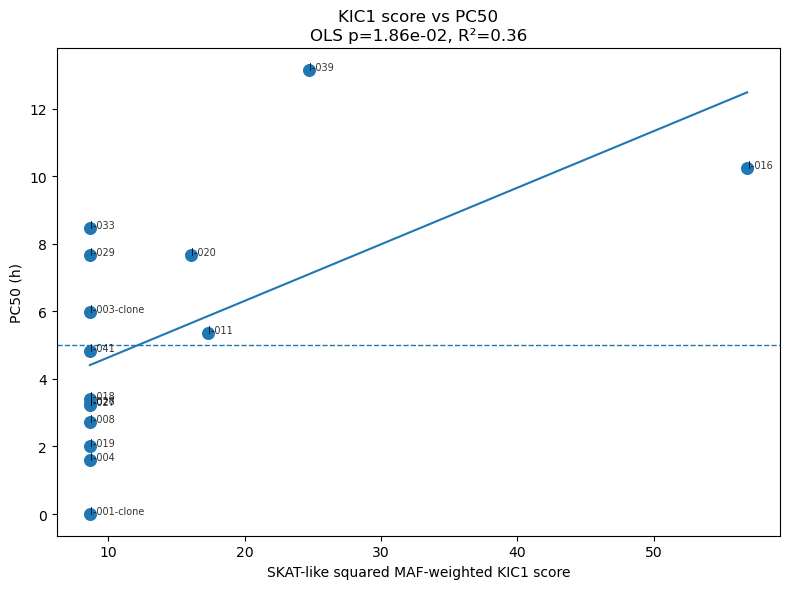

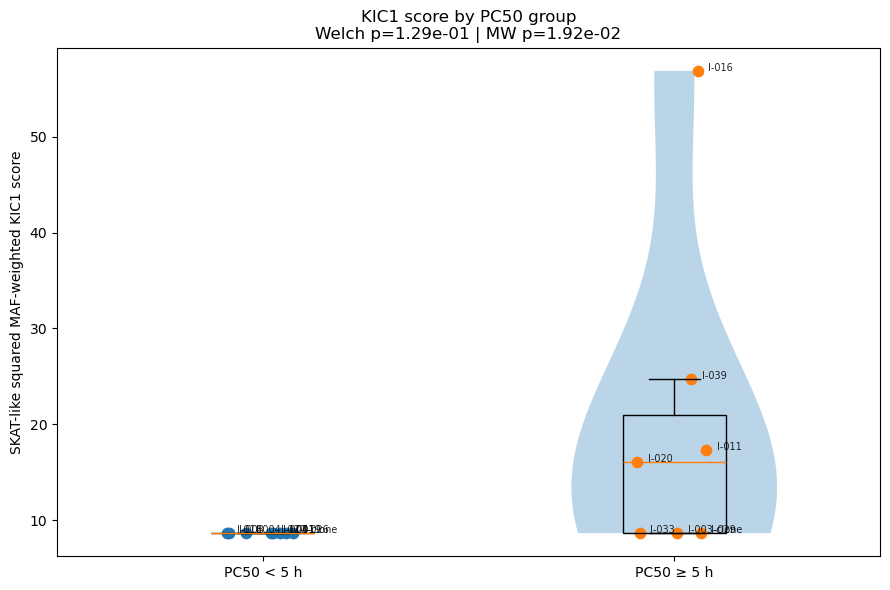

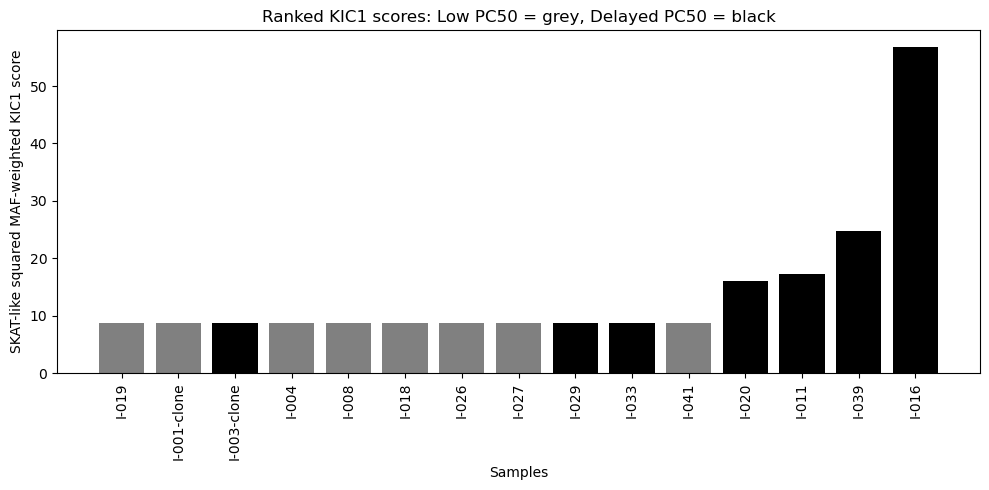


Permutation p = 0.0175

--- Log-score group tests ---
Welch p = 0.06374254942987718
Mann-Whitney p = 0.021329925991210155

STANDARDIZED LOGISTIC REGRESSION
Coefficient = 42.46902642635733
p-value = 0.9999043435658315
Odds ratio = 2.780121835507944e+18
95% CI odds ratio = (0.0, inf)

Full summary:
                           Logit Regression Results                           
Dep. Variable:                 Binary   No. Observations:                   15
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            1
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.3781
Time:                        17:32:29   Log-Likelihood:                -6.4455
converged:                      False   LL-Null:                       -10.364
Covariance Type:            nonrobust   LLR p-value:                  0.005119
                 coef    std err          z      P>|z|      [0.025   

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


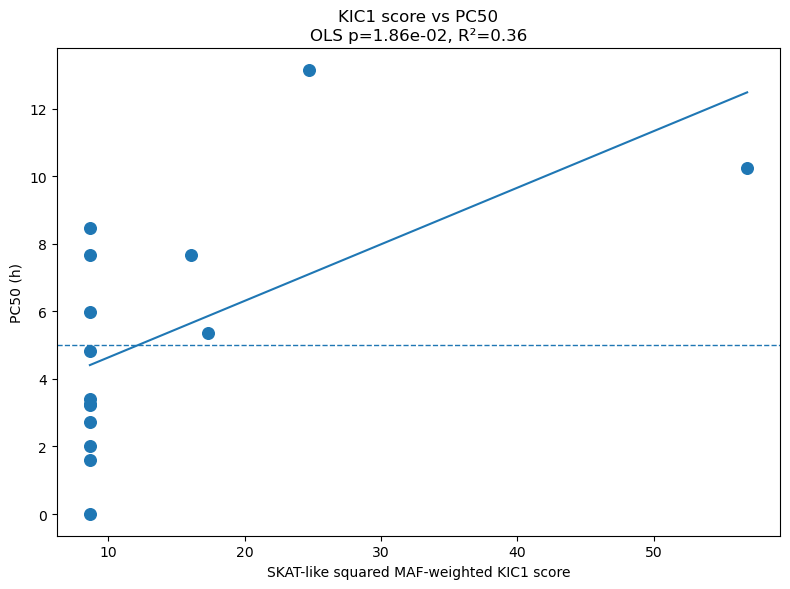

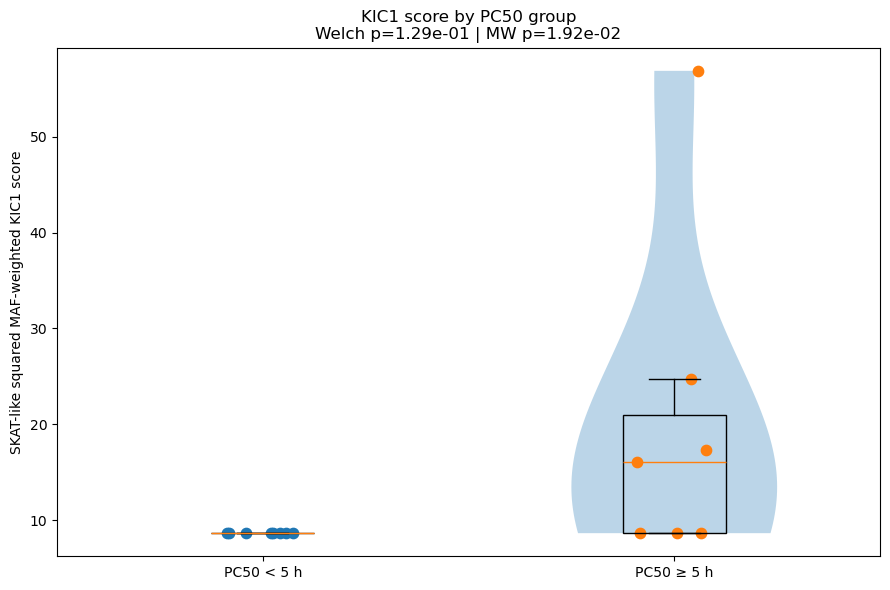

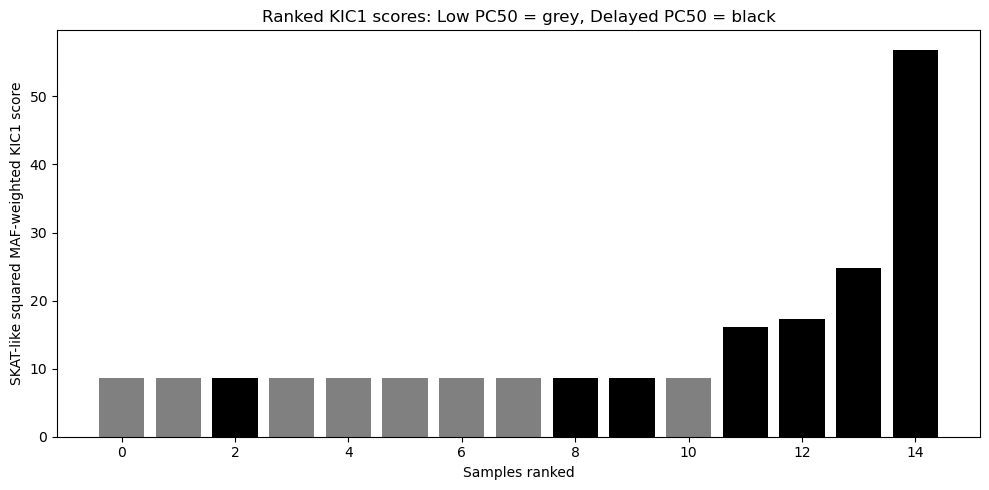


SNPs used in the KIC1 score:
Pf3D7_06_v3:249910:A>T | EFFECT: intergenic_region | REF: A | ALT: T
Pf3D7_06_v3:251284:C>G | EFFECT: missense_variant | REF: C | ALT: G
Pf3D7_06_v3:251742:T>A | EFFECT: missense_variant | REF: T | ALT: A
Pf3D7_06_v3:251778:T>C | EFFECT: missense_variant | REF: T | ALT: C
Pf3D7_06_v3:251809:A>C | EFFECT: missense_variant | REF: A | ALT: C
Pf3D7_06_v3:252876:C>A | EFFECT: missense_variant | REF: C | ALT: A
Pf3D7_06_v3:253113:T>C | EFFECT: missense_variant | REF: T | ALT: C


In [6]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, pearsonr, spearmanr, ranksums
from sklearn.preprocessing import StandardScaler

# ============================================================
# FILE
# ============================================================
geno = pd.read_csv("KIC_1_vcf_subset_BD - Sheet1.csv")

# ============================================================
# PC50 VALUES
# ============================================================
pc50 = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-002", "I-003-clone", "I-004", "I-005",
        "I-008", "I-010", "I-011", "I-013", "I-016",
        "I-017", "I-018", "I-019", "I-020", "I-021",
        "I-025", "I-026", "I-027", "I-029", "I-030",
        "I-031", "I-033", "I-035", "I-036", "I-039",
        "I-041"
    ],
    "PC50": [
        0.015, 3.56, 5.967, 1.6, 3.82,
        2.71, 2.01, 5.35, 7.98, 10.25,
        4.51, 3.42, 2.02, 7.66, 2.83,
        3.39, 3.25, 3.23, 7.68, 8.19,
        3.41, 8.48, 1.25, 9.42, 13.14,
        4.82
    ]
})

pc50["Sample"] = pc50["Sample"].astype(str).str.strip()
pc50["PC50"] = pd.to_numeric(pc50["PC50"], errors="coerce")
pc50 = pc50.dropna()

# ============================================================
# MATCH SAMPLES
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found in genotype file.")

format_idx = list(geno.columns).index("FORMAT")
samples = list(geno.columns[format_idx + 1:])
samples = [str(s).strip() for s in samples]

common = sorted(set(samples).intersection(set(pc50["Sample"])))

print("Samples in VCF:", len(samples))
print("Samples with PC50:", len(pc50))
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching sample names between genotype file and PC50 table.")

pc50_data = pc50.set_index("Sample").loc[common]

# ============================================================
# SNP IDs
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", "."]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

# ============================================================
# PARSE EFFECT FROM ANN
# ============================================================
def get_effect(info):
    if pd.isna(info):
        return None

    for field in str(info).split(";"):
        if field.startswith("ANN="):
            ann = field[4:].split(",")[0]
            parts = ann.split("|")
            if len(parts) > 1:
                return parts[1]

    return None

geno["EFFECT"] = geno["INFO"].apply(get_effect)

# ============================================================
# KEEP ALL RELEVANT SNPs:
# missense + stop_gained + intergenic
# ============================================================
keep = geno["EFFECT"].str.contains(
    "missense|stop_gained|intergenic",
    na=False
)

geno_filt = geno[keep].copy()

print("\nNumber of retained SNPs:", geno_filt.shape[0])
print("\nRetained SNPs:")
for s in geno_filt["SNP_ID"].tolist():
    print(" ", s)

A_filt = A[geno_filt["SNP_ID"]].copy()

# ============================================================
# SKAT-LIKE SQUARED MAF-WEIGHTED GENE SCORE
# Original score: sum(w_j * G_ij)
# New SKAT-like score: sum((w_j * G_ij)^2)
# Since G is binary 0/1, this becomes sum(w_j^2 for present ALT SNPs)
# ============================================================
maf = A_filt.mean(axis=0)

weights = 1 / np.sqrt(maf * (1 - maf))
weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

weighted_alt = A_filt * weights
gene_score = (weighted_alt ** 2).sum(axis=1)

df = pd.DataFrame({
    "Sample": gene_score.index,
    "Score": gene_score.values,
    "PC50": pc50_data.loc[gene_score.index, "PC50"].values
})

df["Group"] = np.where(df["PC50"] >= 5, "Delayed_PC50", "Low_PC50")
df["Binary"] = (df["PC50"] >= 5).astype(int)

df = df.dropna(subset=["PC50", "Score"]).copy()

print("\nAnalysis dataframe:")
print(df.to_string(index=False))

if df["Score"].nunique() <= 1:
    raise ValueError("Score has no variation across samples.")

# ============================================================
# CONTINUOUS ASSOCIATION: PC50 ~ SCORE
# ============================================================
X = sm.add_constant(df["Score"])
fit = sm.OLS(df["PC50"], X).fit()

pearson_r, pearson_p = pearsonr(df["Score"], df["PC50"])
spearman_r, spearman_p = spearmanr(df["Score"], df["PC50"])

# ============================================================
# GROUP TESTS
# ============================================================
low = df[df["Group"] == "Low_PC50"]["Score"]
delayed = df[df["Group"] == "Delayed_PC50"]["Score"]

welch_p = ttest_ind(low, delayed, equal_var=False).pvalue
mw_p = mannwhitneyu(low, delayed, alternative="two-sided").pvalue
wilcox_p = ranksums(low, delayed).pvalue

# ============================================================
# LOGISTIC REGRESSION
# ============================================================
try:
    logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
    logit_beta = logit.params.iloc[1]
    logit_p = logit.pvalues.iloc[1]
    odds_ratio = np.exp(logit_beta)
except Exception as e:
    logit_beta = np.nan
    logit_p = np.nan
    odds_ratio = np.nan
    print("\nLogistic regression failed:", e)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 70)
print("SKAT-LIKE SQUARED MAF-WEIGHTED KIC1 SCORE USING PC50")
print("=" * 70)

print("\nWeights:")
print(weights.to_string())

print("\nSquared weights:")
print((weights ** 2).to_string())

print("\n--- Continuous association: PC50 ~ Score ---")
print(f"OLS beta = {fit.params.iloc[1]:.12f}")
print(f"OLS p = {fit.pvalues.iloc[1]:.12g}")
print(f"R^2 = {fit.rsquared:.12f}")
print(f"Pearson r = {pearson_r:.12f}, p = {pearson_p:.12g}")
print(f"Spearman rho = {spearman_r:.12f}, p = {spearman_p:.12g}")

print("\n--- Group tests: PC50 < 5 h vs PC50 >= 5 h ---")
print(f"Welch t-test p = {welch_p:.12g}")
print(f"Mann-Whitney p = {mw_p:.12g}")
print(f"Wilcoxon rank-sum p = {wilcox_p:.12g}")

print("\n--- Logistic regression: Delayed PC50 ~ Score ---")
print(f"Logistic beta = {logit_beta}")
print(f"Logistic p = {logit_p}")
print(f"Odds ratio = {odds_ratio}")

print("\n--- Group means ---")
print(f"Low PC50 mean score = {low.mean():.12f}")
print(f"Delayed PC50 mean score = {delayed.mean():.12f}")

print("\n--- Sample-level scores ---")
print(df.to_string(index=False))

# ============================================================
# PLOT 1: SCORE VS PC50 WITH SAMPLE LABELS
# ============================================================
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["PC50"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(5, linestyle="--", linewidth=1)

for _, row in df.iterrows():
    plt.text(
        row["Score"] + 0.03,
        row["PC50"],
        row["Sample"],
        fontsize=7,
        alpha=0.8
    )

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("PC50 (h)")
plt.title(f"KIC1 score vs PC50\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: VIOLIN + BOX + POINTS + SAMPLE LABELS
# ============================================================
plt.figure(figsize=(9, 6))

df_plot = df.copy()

plot_groups = [
    df_plot[df_plot["Group"] == "Low_PC50"],
    df_plot[df_plot["Group"] == "Delayed_PC50"]
]

pos = [1, 2]

plt.violinplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    showextrema=False
)

bp = plt.boxplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, d in enumerate(plot_groups):
    x_center = pos[i]
    xj = np.full(len(d), x_center, dtype=float) + rng.uniform(-0.09, 0.09, len(d))
    yj = d["Score"].values
    labels = d["Sample"].values

    plt.scatter(xj, yj, s=55)

    for x, y, label in zip(xj, yj, labels):
        plt.text(
            x + 0.025,
            y,
            label,
            fontsize=7,
            alpha=0.85
        )

plt.xticks(pos, ["PC50 < 5 h", "PC50 ≥ 5 h"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by PC50 group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: RANKED BAR PLOT WITH SAMPLE NAMES
# ============================================================
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Low_PC50" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.xticks(range(len(df_sorted)), df_sorted["Sample"], rotation=90)
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples")
plt.title("Ranked KIC1 scores: Low PC50 = grey, Delayed PC50 = black")

plt.tight_layout()
plt.show()

# ============================================================
# PERMUTATION TEST
# ============================================================
obs_diff = delayed.mean() - low.mean()

perm_diffs = []
rng = np.random.default_rng(1)

for _ in range(10000):
    shuffled = rng.permutation(df["Score"].values)
    perm_low = shuffled[:len(low)]
    perm_delayed = shuffled[len(low):]
    perm_diffs.append(perm_delayed.mean() - perm_low.mean())

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

print("\nPermutation p =", p_perm)

# ============================================================
# LOG-TRANSFORMED SCORE TEST
# ============================================================
df["Score_log"] = np.log1p(df["Score"])

low_log = df[df["Group"] == "Low_PC50"]["Score_log"]
delayed_log = df[df["Group"] == "Delayed_PC50"]["Score_log"]

print("\n--- Log-score group tests ---")
print("Welch p =", ttest_ind(low_log, delayed_log, equal_var=False).pvalue)
print("Mann-Whitney p =", mannwhitneyu(low_log, delayed_log, alternative="two-sided").pvalue)

# ============================================================
# STANDARDIZED LOGISTIC REGRESSION
# ============================================================
scaler = StandardScaler()
df["Score_z"] = scaler.fit_transform(df[["Score"]])

try:
    X_z = sm.add_constant(df["Score_z"])
    y_bin = df["Binary"]

    logit_z = sm.Logit(y_bin, X_z).fit(disp=0)

    print("\n" + "=" * 60)
    print("STANDARDIZED LOGISTIC REGRESSION")
    print("=" * 60)
    print("Coefficient =", logit_z.params["Score_z"])
    print("p-value =", logit_z.pvalues["Score_z"])
    print("Odds ratio =", np.exp(logit_z.params["Score_z"]))

    conf = logit_z.conf_int().loc["Score_z"]
    conf_odds = np.exp(conf)
    print("95% CI odds ratio =", tuple(conf_odds))

    print("\nFull summary:")
    print(logit_z.summary())

except Exception as e:
    print("\nStandardized logistic regression failed:", e)

# ============================================================
# PLOTTING BLOCK WITHOUT SAMPLE NAME LABELS
# ============================================================

# ------------------------------------------------------------
# PLOT 1: SCORE VS PC50, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["PC50"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(5, linestyle="--", linewidth=1)

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("PC50 (h)")
plt.title(f"KIC1 score vs PC50\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2: VIOLIN + BOX + POINTS, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

data = [low.values, delayed.values]
pos = [1, 2]

plt.violinplot(data, positions=pos, showextrema=False)

bp = plt.boxplot(
    data,
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, arr in enumerate(data):
    xj = np.full(len(arr), pos[i], dtype=float) + rng.uniform(-0.09, 0.09, len(arr))
    plt.scatter(xj, arr, s=55)

plt.xticks(pos, ["PC50 < 5 h", "PC50 ≥ 5 h"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by PC50 group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3: RANKED BAR PLOT, NO SAMPLE NAMES ON BARS
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Low_PC50" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples ranked")
plt.title("Ranked KIC1 scores: Low PC50 = grey, Delayed PC50 = black")

plt.tight_layout()
plt.show()


print("\nSNPs used in the KIC1 score:")
for i, row in geno_filt.iterrows():
    print(
        row["SNP_ID"],
        "| EFFECT:",
        row["EFFECT"],
        "| REF:",
        row["REF"],
        "| ALT:",
        row["ALT"]
    )

Samples in VCF: 20
Samples with PC50: 26
Matched samples: 15
['I-001-clone', 'I-003-clone', 'I-004', 'I-008', 'I-011', 'I-016', 'I-018', 'I-019', 'I-020', 'I-026', 'I-027', 'I-029', 'I-033', 'I-039', 'I-041']

Number of retained SNPs: 7

Retained SNPs:
  Pf3D7_06_v3:249910:A>T
  Pf3D7_06_v3:251284:C>G
  Pf3D7_06_v3:251742:T>A
  Pf3D7_06_v3:251778:T>C
  Pf3D7_06_v3:251809:A>C
  Pf3D7_06_v3:252876:C>A
  Pf3D7_06_v3:253113:T>C

Analysis dataframe:
     Sample     Score   PC50        Group  Binary
I-001-clone  8.653846  0.015     Low_PC50       0
I-003-clone  8.653846  5.967 Delayed_PC50       1
      I-004  8.653846  1.600     Low_PC50       0
      I-008  8.653846  2.710     Low_PC50       0
      I-011 17.307692  5.350 Delayed_PC50       1
      I-016 56.868132 10.250 Delayed_PC50       1
      I-018  8.653846  3.420     Low_PC50       0
      I-019  8.653846  2.020     Low_PC50       0
      I-020 16.071429  7.660 Delayed_PC50       1
      I-026  8.653846  3.250     Low_PC50       0
 

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


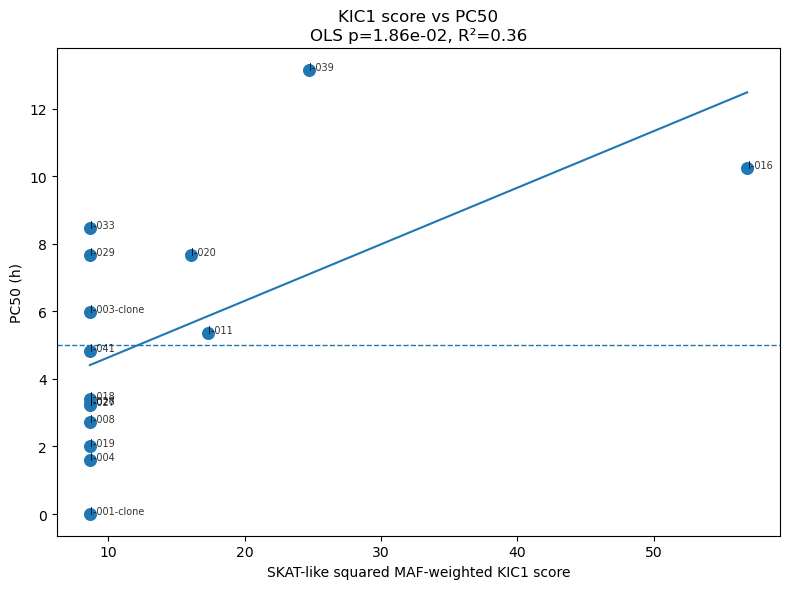

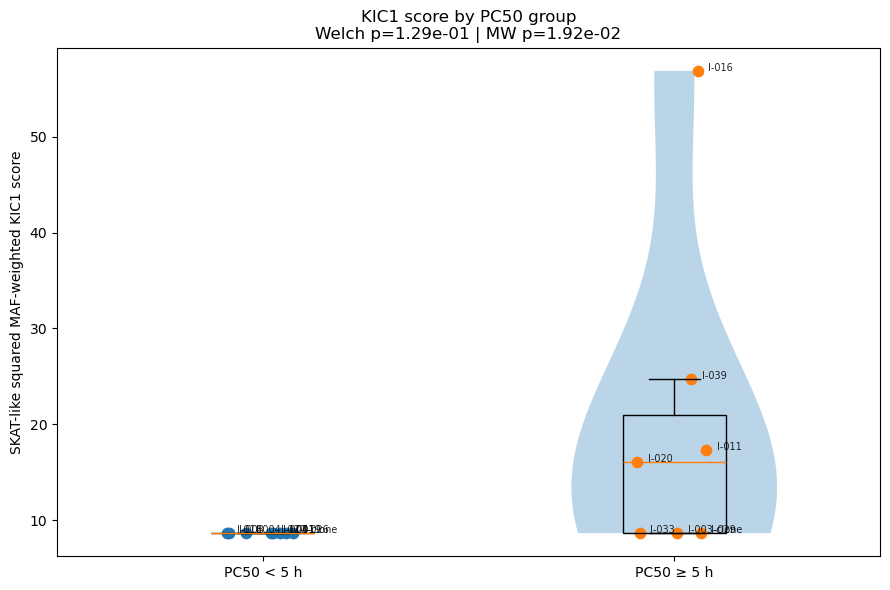

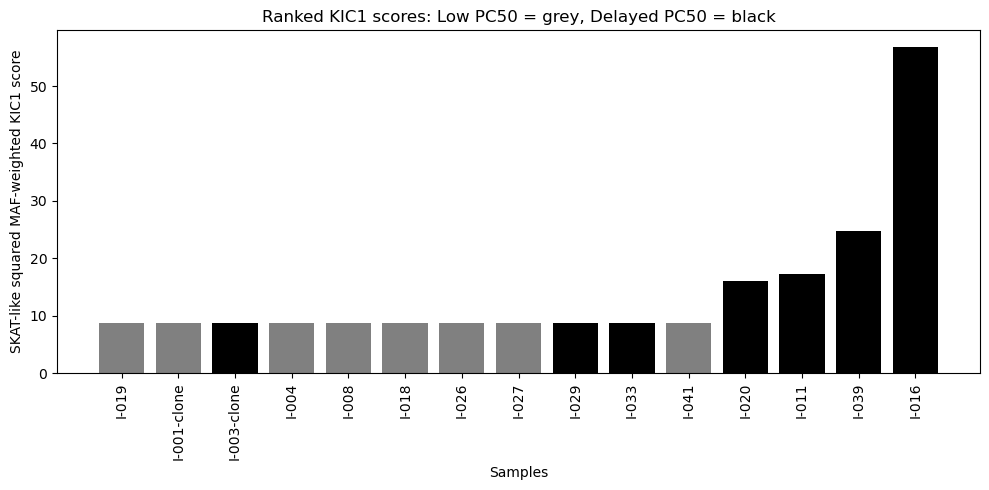


Permutation p = 0.0175

--- Log-score group tests ---
Welch p = 0.06374254942987718
Mann-Whitney p = 0.021329925991210155

STANDARDIZED LOGISTIC REGRESSION
Coefficient = 42.46902642635733
p-value = 0.9999043435658315
Odds ratio = 2.780121835507944e+18
95% CI odds ratio = (0.0, inf)

Full summary:
                           Logit Regression Results                           
Dep. Variable:                 Binary   No. Observations:                   15
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            1
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.3781
Time:                        18:27:53   Log-Likelihood:                -6.4455
converged:                      False   LL-Null:                       -10.364
Covariance Type:            nonrobust   LLR p-value:                  0.005119
                 coef    std err          z      P>|z|      [0.025   

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


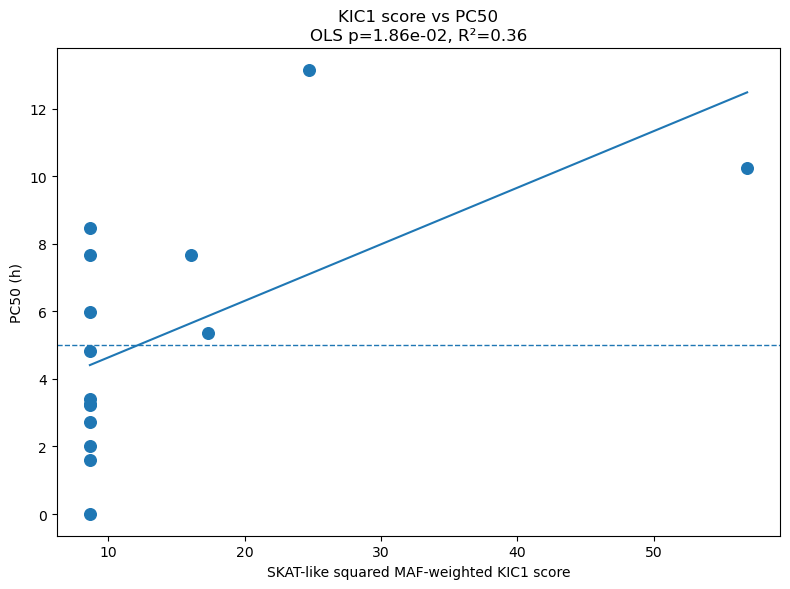

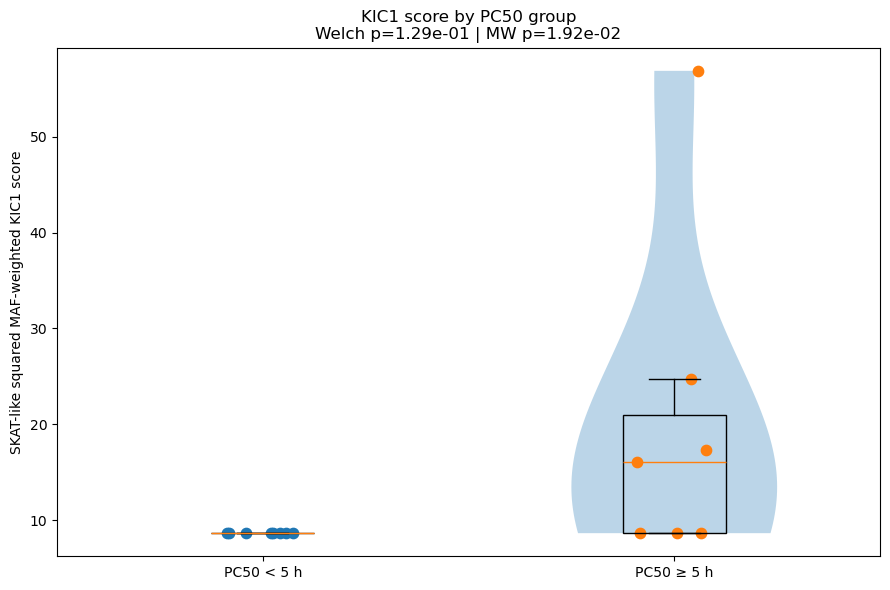

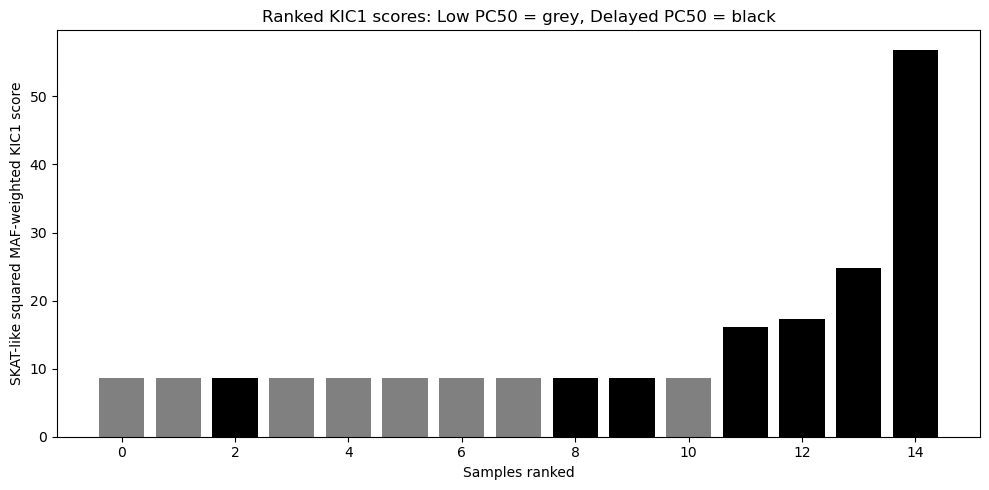


SNPs used in the KIC1 score:
Pf3D7_06_v3:249910:A>T | EFFECT: intergenic_region | REF: A | ALT: T
Pf3D7_06_v3:251284:C>G | EFFECT: missense_variant | REF: C | ALT: G
Pf3D7_06_v3:251742:T>A | EFFECT: missense_variant | REF: T | ALT: A
Pf3D7_06_v3:251778:T>C | EFFECT: missense_variant | REF: T | ALT: C
Pf3D7_06_v3:251809:A>C | EFFECT: missense_variant | REF: A | ALT: C
Pf3D7_06_v3:252876:C>A | EFFECT: missense_variant | REF: C | ALT: A
Pf3D7_06_v3:253113:T>C | EFFECT: missense_variant | REF: T | ALT: C

PENALIZED REGRESSION (ELASTIC NET) ON KIC1 PER-SNP FEATURES
Design matrix shape: (15, 7)
Features (SNPs):     7
Samples:             15

--- Selected hyperparameters (LOOCV) ---
Optimal lambda (sklearn alpha): 1.007009
Optimal mixing l1_ratio:        0.90

--- Final coefficients ---
                SNP_ID  MB_weight  Coefficient  Selected
Pf3D7_06_v3:249910:A>T   4.008919     1.109780      True
Pf3D7_06_v3:251284:C>G   2.941742     0.000000     False
Pf3D7_06_v3:251742:T>A   4.008919    

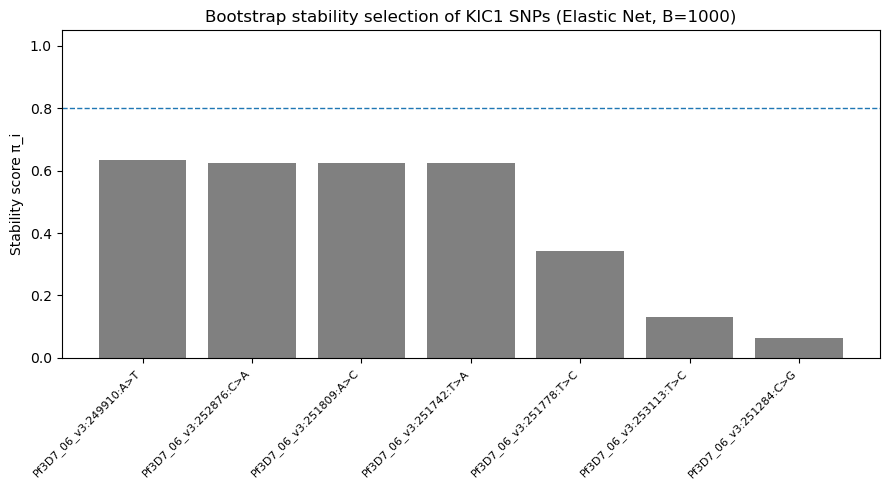

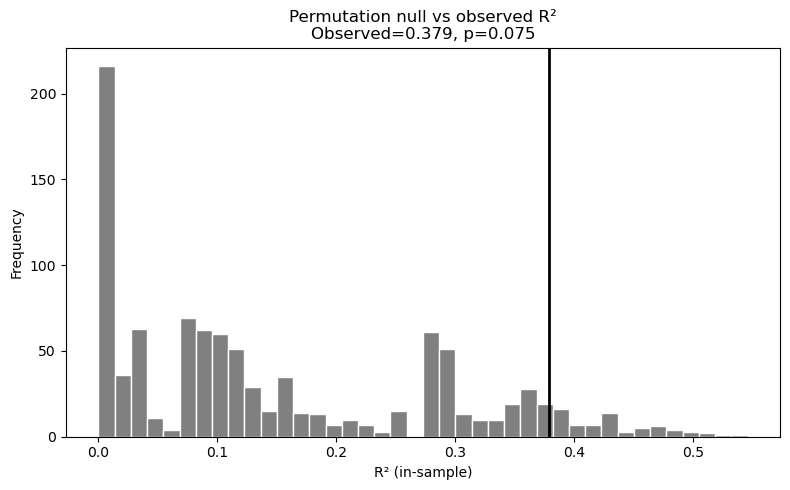

In [7]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, pearsonr, spearmanr, ranksums
from sklearn.preprocessing import StandardScaler

# ============================================================
# FILE
# ============================================================
geno = pd.read_csv("KIC_1_vcf_subset_BD - Sheet1.csv")

# ============================================================
# PC50 VALUES
# ============================================================
pc50 = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-002", "I-003-clone", "I-004", "I-005",
        "I-008", "I-010", "I-011", "I-013", "I-016",
        "I-017", "I-018", "I-019", "I-020", "I-021",
        "I-025", "I-026", "I-027", "I-029", "I-030",
        "I-031", "I-033", "I-035", "I-036", "I-039",
        "I-041"
    ],
    "PC50": [
        0.015, 3.56, 5.967, 1.6, 3.82,
        2.71, 2.01, 5.35, 7.98, 10.25,
        4.51, 3.42, 2.02, 7.66, 2.83,
        3.39, 3.25, 3.23, 7.68, 8.19,
        3.41, 8.48, 1.25, 9.42, 13.14,
        4.82
    ]
})

pc50["Sample"] = pc50["Sample"].astype(str).str.strip()
pc50["PC50"] = pd.to_numeric(pc50["PC50"], errors="coerce")
pc50 = pc50.dropna()

# ============================================================
# MATCH SAMPLES
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found in genotype file.")

format_idx = list(geno.columns).index("FORMAT")
samples = list(geno.columns[format_idx + 1:])
samples = [str(s).strip() for s in samples]

common = sorted(set(samples).intersection(set(pc50["Sample"])))

print("Samples in VCF:", len(samples))
print("Samples with PC50:", len(pc50))
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching sample names between genotype file and PC50 table.")

pc50_data = pc50.set_index("Sample").loc[common]

# ============================================================
# SNP IDs
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", "."]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

# ============================================================
# PARSE EFFECT FROM ANN
# ============================================================
def get_effect(info):
    if pd.isna(info):
        return None

    for field in str(info).split(";"):
        if field.startswith("ANN="):
            ann = field[4:].split(",")[0]
            parts = ann.split("|")
            if len(parts) > 1:
                return parts[1]

    return None

geno["EFFECT"] = geno["INFO"].apply(get_effect)

# ============================================================
# KEEP ALL RELEVANT SNPs:
# missense + stop_gained + intergenic
# ============================================================
keep = geno["EFFECT"].str.contains(
    "missense|stop_gained|intergenic",
    na=False
)

geno_filt = geno[keep].copy()

print("\nNumber of retained SNPs:", geno_filt.shape[0])
print("\nRetained SNPs:")
for s in geno_filt["SNP_ID"].tolist():
    print(" ", s)

A_filt = A[geno_filt["SNP_ID"]].copy()

# ============================================================
# SKAT-LIKE SQUARED MAF-WEIGHTED GENE SCORE
# Original score: sum(w_j * G_ij)
# New SKAT-like score: sum((w_j * G_ij)^2)
# Since G is binary 0/1, this becomes sum(w_j^2 for present ALT SNPs)
# ============================================================
maf = A_filt.mean(axis=0)

weights = 1 / np.sqrt(maf * (1 - maf))
weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

weighted_alt = A_filt * weights
gene_score = (weighted_alt ** 2).sum(axis=1)

df = pd.DataFrame({
    "Sample": gene_score.index,
    "Score": gene_score.values,
    "PC50": pc50_data.loc[gene_score.index, "PC50"].values
})

df["Group"] = np.where(df["PC50"] >= 5, "Delayed_PC50", "Low_PC50")
df["Binary"] = (df["PC50"] >= 5).astype(int)

df = df.dropna(subset=["PC50", "Score"]).copy()

print("\nAnalysis dataframe:")
print(df.to_string(index=False))

if df["Score"].nunique() <= 1:
    raise ValueError("Score has no variation across samples.")

# ============================================================
# CONTINUOUS ASSOCIATION: PC50 ~ SCORE
# ============================================================
X = sm.add_constant(df["Score"])
fit = sm.OLS(df["PC50"], X).fit()

pearson_r, pearson_p = pearsonr(df["Score"], df["PC50"])
spearman_r, spearman_p = spearmanr(df["Score"], df["PC50"])

# ============================================================
# GROUP TESTS
# ============================================================
low = df[df["Group"] == "Low_PC50"]["Score"]
delayed = df[df["Group"] == "Delayed_PC50"]["Score"]

welch_p = ttest_ind(low, delayed, equal_var=False).pvalue
mw_p = mannwhitneyu(low, delayed, alternative="two-sided").pvalue
wilcox_p = ranksums(low, delayed).pvalue

# ============================================================
# LOGISTIC REGRESSION
# ============================================================
try:
    logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
    logit_beta = logit.params.iloc[1]
    logit_p = logit.pvalues.iloc[1]
    odds_ratio = np.exp(logit_beta)
except Exception as e:
    logit_beta = np.nan
    logit_p = np.nan
    odds_ratio = np.nan
    print("\nLogistic regression failed:", e)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 70)
print("SKAT-LIKE SQUARED MAF-WEIGHTED KIC1 SCORE USING PC50")
print("=" * 70)

print("\nWeights:")
print(weights.to_string())

print("\nSquared weights:")
print((weights ** 2).to_string())

print("\n--- Continuous association: PC50 ~ Score ---")
print(f"OLS beta = {fit.params.iloc[1]:.12f}")
print(f"OLS p = {fit.pvalues.iloc[1]:.12g}")
print(f"R^2 = {fit.rsquared:.12f}")
print(f"Pearson r = {pearson_r:.12f}, p = {pearson_p:.12g}")
print(f"Spearman rho = {spearman_r:.12f}, p = {spearman_p:.12g}")

print("\n--- Group tests: PC50 < 5 h vs PC50 >= 5 h ---")
print(f"Welch t-test p = {welch_p:.12g}")
print(f"Mann-Whitney p = {mw_p:.12g}")
print(f"Wilcoxon rank-sum p = {wilcox_p:.12g}")

print("\n--- Logistic regression: Delayed PC50 ~ Score ---")
print(f"Logistic beta = {logit_beta}")
print(f"Logistic p = {logit_p}")
print(f"Odds ratio = {odds_ratio}")

print("\n--- Group means ---")
print(f"Low PC50 mean score = {low.mean():.12f}")
print(f"Delayed PC50 mean score = {delayed.mean():.12f}")

print("\n--- Sample-level scores ---")
print(df.to_string(index=False))

# ============================================================
# PLOT 1: SCORE VS PC50 WITH SAMPLE LABELS
# ============================================================
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["PC50"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(5, linestyle="--", linewidth=1)

for _, row in df.iterrows():
    plt.text(
        row["Score"] + 0.03,
        row["PC50"],
        row["Sample"],
        fontsize=7,
        alpha=0.8
    )

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("PC50 (h)")
plt.title(f"KIC1 score vs PC50\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: VIOLIN + BOX + POINTS + SAMPLE LABELS
# ============================================================
plt.figure(figsize=(9, 6))

df_plot = df.copy()

plot_groups = [
    df_plot[df_plot["Group"] == "Low_PC50"],
    df_plot[df_plot["Group"] == "Delayed_PC50"]
]

pos = [1, 2]

plt.violinplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    showextrema=False
)

bp = plt.boxplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, d in enumerate(plot_groups):
    x_center = pos[i]
    xj = np.full(len(d), x_center, dtype=float) + rng.uniform(-0.09, 0.09, len(d))
    yj = d["Score"].values
    labels = d["Sample"].values

    plt.scatter(xj, yj, s=55)

    for x, y, label in zip(xj, yj, labels):
        plt.text(
            x + 0.025,
            y,
            label,
            fontsize=7,
            alpha=0.85
        )

plt.xticks(pos, ["PC50 < 5 h", "PC50 ≥ 5 h"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by PC50 group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: RANKED BAR PLOT WITH SAMPLE NAMES
# ============================================================
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Low_PC50" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.xticks(range(len(df_sorted)), df_sorted["Sample"], rotation=90)
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples")
plt.title("Ranked KIC1 scores: Low PC50 = grey, Delayed PC50 = black")

plt.tight_layout()
plt.show()

# ============================================================
# PERMUTATION TEST
# ============================================================
obs_diff = delayed.mean() - low.mean()

perm_diffs = []
rng = np.random.default_rng(1)

for _ in range(10000):
    shuffled = rng.permutation(df["Score"].values)
    perm_low = shuffled[:len(low)]
    perm_delayed = shuffled[len(low):]
    perm_diffs.append(perm_delayed.mean() - perm_low.mean())

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

print("\nPermutation p =", p_perm)

# ============================================================
# LOG-TRANSFORMED SCORE TEST
# ============================================================
df["Score_log"] = np.log1p(df["Score"])

low_log = df[df["Group"] == "Low_PC50"]["Score_log"]
delayed_log = df[df["Group"] == "Delayed_PC50"]["Score_log"]

print("\n--- Log-score group tests ---")
print("Welch p =", ttest_ind(low_log, delayed_log, equal_var=False).pvalue)
print("Mann-Whitney p =", mannwhitneyu(low_log, delayed_log, alternative="two-sided").pvalue)

# ============================================================
# STANDARDIZED LOGISTIC REGRESSION
# ============================================================
scaler = StandardScaler()
df["Score_z"] = scaler.fit_transform(df[["Score"]])

try:
    X_z = sm.add_constant(df["Score_z"])
    y_bin = df["Binary"]

    logit_z = sm.Logit(y_bin, X_z).fit(disp=0)

    print("\n" + "=" * 60)
    print("STANDARDIZED LOGISTIC REGRESSION")
    print("=" * 60)
    print("Coefficient =", logit_z.params["Score_z"])
    print("p-value =", logit_z.pvalues["Score_z"])
    print("Odds ratio =", np.exp(logit_z.params["Score_z"]))

    conf = logit_z.conf_int().loc["Score_z"]
    conf_odds = np.exp(conf)
    print("95% CI odds ratio =", tuple(conf_odds))

    print("\nFull summary:")
    print(logit_z.summary())

except Exception as e:
    print("\nStandardized logistic regression failed:", e)

# ============================================================
# PLOTTING BLOCK WITHOUT SAMPLE NAME LABELS
# ============================================================

# ------------------------------------------------------------
# PLOT 1: SCORE VS PC50, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["PC50"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(5, linestyle="--", linewidth=1)

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("PC50 (h)")
plt.title(f"KIC1 score vs PC50\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2: VIOLIN + BOX + POINTS, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

data = [low.values, delayed.values]
pos = [1, 2]

plt.violinplot(data, positions=pos, showextrema=False)

bp = plt.boxplot(
    data,
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, arr in enumerate(data):
    xj = np.full(len(arr), pos[i], dtype=float) + rng.uniform(-0.09, 0.09, len(arr))
    plt.scatter(xj, arr, s=55)

plt.xticks(pos, ["PC50 < 5 h", "PC50 ≥ 5 h"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by PC50 group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3: RANKED BAR PLOT, NO SAMPLE NAMES ON BARS
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Low_PC50" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples ranked")
plt.title("Ranked KIC1 scores: Low PC50 = grey, Delayed PC50 = black")

plt.tight_layout()
plt.show()


print("\nSNPs used in the KIC1 score:")
for i, row in geno_filt.iterrows():
    print(
        row["SNP_ID"],
        "| EFFECT:",
        row["EFFECT"],
        "| REF:",
        row["REF"],
        "| ALT:",
        row["ALT"]
    )


# ============================================================
# PENALIZED REGRESSION EXTENSION
# Append this block to your existing KIC1 analysis script.
# Requires: A_filt, weights, df (already constructed above)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
from sklearn.utils import resample

# ------------------------------------------------------------
# STEP 1: Construct the weighted per-SNP feature matrix
# A_tilde_{ji} = w_i * A_{ji}
# Shape: (n_samples, m_snps) = (15, 7)
# ------------------------------------------------------------
A_tilde = A_filt.multiply(weights, axis=1)
A_tilde = A_tilde.loc[df["Sample"].values]   # align row order to df

X_ml = A_tilde.values                         # design matrix
y_ml = df["PC50"].values                      # continuous outcome
snp_names = A_tilde.columns.tolist()

print("\n" + "=" * 70)
print("PENALIZED REGRESSION (ELASTIC NET) ON KIC1 PER-SNP FEATURES")
print("=" * 70)
print(f"Design matrix shape: {X_ml.shape}")
print(f"Features (SNPs):     {len(snp_names)}")
print(f"Samples:             {X_ml.shape[0]}")

# ------------------------------------------------------------
# STEP 2 + 3: Elastic net with LOOCV over (alpha, l1_ratio)
# sklearn parameterization:
#   alpha       <-> lambda  (penalty strength)
#   l1_ratio    <-> alpha   (mixing: 1 = lasso, 0 = ridge)
# ------------------------------------------------------------
loo = LeaveOneOut()
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

enet_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    n_alphas=100,
    cv=loo,
    max_iter=20000,
    fit_intercept=True,
    random_state=0,
)

enet_cv.fit(X_ml, y_ml)

print("\n--- Selected hyperparameters (LOOCV) ---")
print(f"Optimal lambda (sklearn alpha): {enet_cv.alpha_:.6f}")
print(f"Optimal mixing l1_ratio:        {enet_cv.l1_ratio_:.2f}")

# ------------------------------------------------------------
# Refit at the optimal hyperparameters on full data
# ------------------------------------------------------------
enet_final = ElasticNet(
    alpha=enet_cv.alpha_,
    l1_ratio=enet_cv.l1_ratio_,
    max_iter=20000,
    fit_intercept=True,
)
enet_final.fit(X_ml, y_ml)

coef_table = pd.DataFrame({
    "SNP_ID": snp_names,
    "MB_weight": weights[snp_names].values,
    "Coefficient": enet_final.coef_,
    "Selected": enet_final.coef_ != 0,
})

print("\n--- Final coefficients ---")
print(coef_table.to_string(index=False))
print(f"\nNumber of SNPs with non-zero coefficient: "
      f"{int(coef_table['Selected'].sum())} / {len(snp_names)}")

# ------------------------------------------------------------
# STEP 4: Bootstrap stability selection
# pi_i = fraction of bootstrap resamples where SNP i is selected
# ------------------------------------------------------------
B = 1000
rng_boot = np.random.default_rng(42)
n_samples = X_ml.shape[0]
selection_matrix = np.zeros((B, len(snp_names)), dtype=int)

for b in range(B):
    idx = rng_boot.choice(n_samples, size=n_samples, replace=True)
    X_b, y_b = X_ml[idx], y_ml[idx]
    try:
        model_b = ElasticNet(
            alpha=enet_cv.alpha_,
            l1_ratio=enet_cv.l1_ratio_,
            max_iter=20000,
            fit_intercept=True,
        )
        model_b.fit(X_b, y_b)
        selection_matrix[b] = (model_b.coef_ != 0).astype(int)
    except Exception:
        selection_matrix[b] = 0

stability = selection_matrix.mean(axis=0)

stability_table = pd.DataFrame({
    "SNP_ID": snp_names,
    "MB_weight": weights[snp_names].values,
    "Final_coef": enet_final.coef_,
    "Stability_pi": stability,
    "Robust_pi>=0.8": stability >= 0.8,
}).sort_values("Stability_pi", ascending=False)

print("\n--- Stability selection (B = 1000 bootstrap resamples) ---")
print(stability_table.to_string(index=False))

# ------------------------------------------------------------
# STEP 5: Permutation test on full-model R^2
# ------------------------------------------------------------
y_pred_obs = enet_final.predict(X_ml)
r2_obs = r2_score(y_ml, y_pred_obs)

n_perm = 1000
rng_perm = np.random.default_rng(7)
r2_null = np.zeros(n_perm)

for b in range(n_perm):
    y_perm = rng_perm.permutation(y_ml)
    model_p = ElasticNet(
        alpha=enet_cv.alpha_,
        l1_ratio=enet_cv.l1_ratio_,
        max_iter=20000,
        fit_intercept=True,
    )
    model_p.fit(X_ml, y_perm)
    r2_null[b] = r2_score(y_perm, model_p.predict(X_ml))

p_perm_r2 = (1 + np.sum(r2_null >= r2_obs)) / (1 + n_perm)

print("\n--- Permutation test of model R^2 ---")
print(f"Observed in-sample R^2: {r2_obs:.4f}")
print(f"Null R^2 mean:          {r2_null.mean():.4f}")
print(f"Null R^2 95th pct:      {np.quantile(r2_null, 0.95):.4f}")
print(f"Permutation p-value:    {p_perm_r2:.4f}")

# ------------------------------------------------------------
# PLOT: Stability scores per SNP
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
order = np.argsort(stability)[::-1]
plt.bar(range(len(snp_names)),
        stability[order],
        color=["black" if stability[i] >= 0.8 else "grey" for i in order])
plt.axhline(0.8, linestyle="--", linewidth=1)
plt.xticks(range(len(snp_names)),
           [snp_names[i] for i in order],
           rotation=45, ha="right", fontsize=8)
plt.ylabel("Stability score π_i")
plt.ylim(0, 1.05)
plt.title("Bootstrap stability selection of KIC1 SNPs (Elastic Net, B=1000)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT: Observed vs null R^2 distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(r2_null, bins=40, color="grey", edgecolor="white")
plt.axvline(r2_obs, color="black", linewidth=2)
plt.xlabel("R² (in-sample)")
plt.ylabel("Frequency")
plt.title(f"Permutation null vs observed R²\nObserved={r2_obs:.3f}, p={p_perm_r2:.3f}")
plt.tight_layout()
plt.show()

Association of KIC1 using RSA

RSA phenotype table:
     Sample      RSA         Group  Binary
I-001-clone 0.663573 Sensitive_RSA       0
I-003-clone 2.007395 Resistant_RSA       1
      I-004 0.000000 Sensitive_RSA       0
      I-011 0.605756 Sensitive_RSA       0
      I-016 4.634667 Resistant_RSA       1
      I-018 0.746667 Sensitive_RSA       0
      I-020 1.760000 Resistant_RSA       1
      I-029 6.443333 Resistant_RSA       1
      I-026 0.653333 Sensitive_RSA       0
      I-033 1.889667 Resistant_RSA       1
      I-039 4.891667 Resistant_RSA       1
      I-041 1.358667 Resistant_RSA       1
      I-040 0.746667 Sensitive_RSA       0
      I-027 0.559333 Sensitive_RSA       0
      O-024 1.730000 Resistant_RSA       1
      I-008 1.535667 Resistant_RSA       1
      I-002 2.563333 Resistant_RSA       1
      O-014 2.126667 Resistant_RSA       1
      O-009 0.420000 Sensitive_RSA       0
      O-032 0.783000 Sensitive_RSA       0
      O-038 1.371667 Resistant_RSA       1
      I-019 0.463333 Sensitive_RS

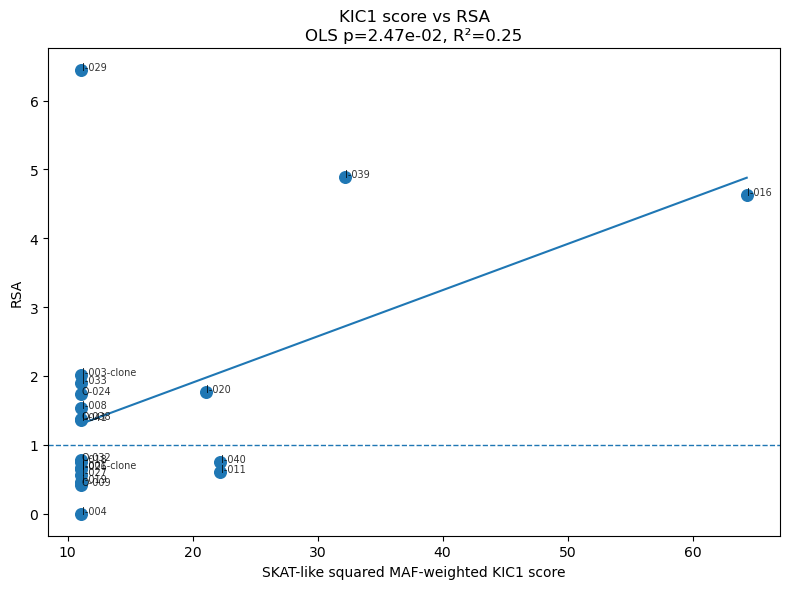

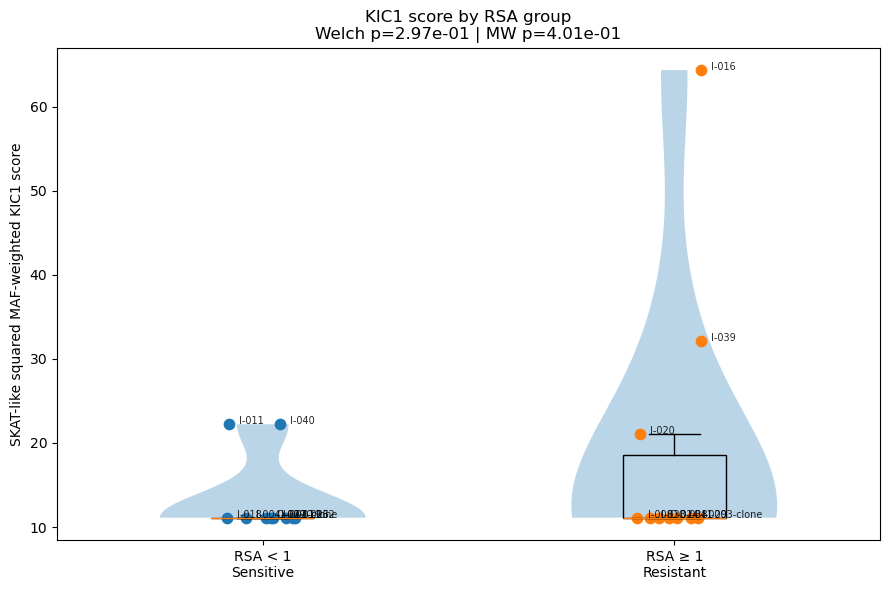

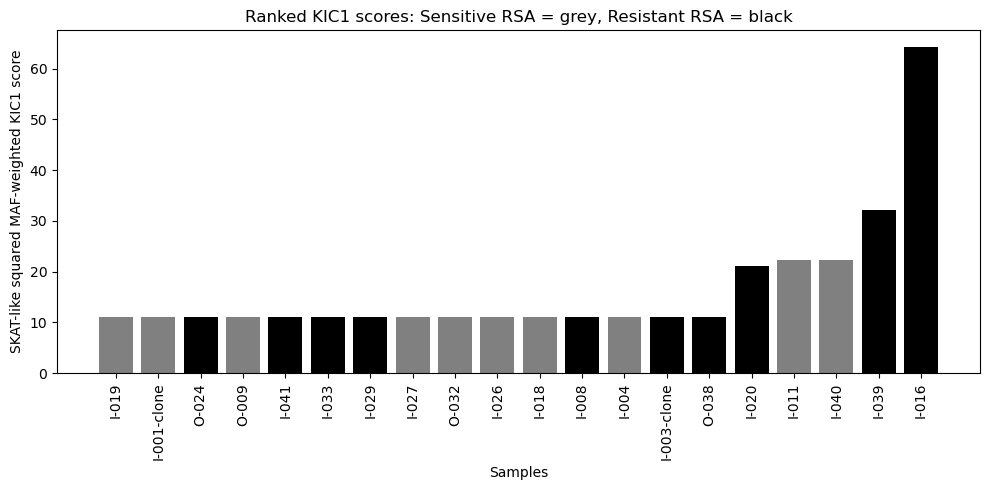


Permutation p = 0.4636

--- Log-score group tests ---
Welch p = 0.35138969281605337
Mann-Whitney p = 0.5845353391489482

STANDARDIZED LOGISTIC REGRESSION
Coefficient = 0.7017511308541103
p-value = 0.34054041496914655
Odds ratio = 2.0172821413174242
95% CI odds ratio = (0.4764751813238601, 8.54069088419576)

Full summary:
                           Logit Regression Results                           
Dep. Variable:                 Binary   No. Observations:                   20
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            1
Date:                Fri, 01 May 2026   Pseudo R-squ.:                 0.05291
Time:                        17:30:55   Log-Likelihood:                -13.129
converged:                       True   LL-Null:                       -13.863
Covariance Type:            nonrobust   LLR p-value:                    0.2258
                 coef    std err          z 

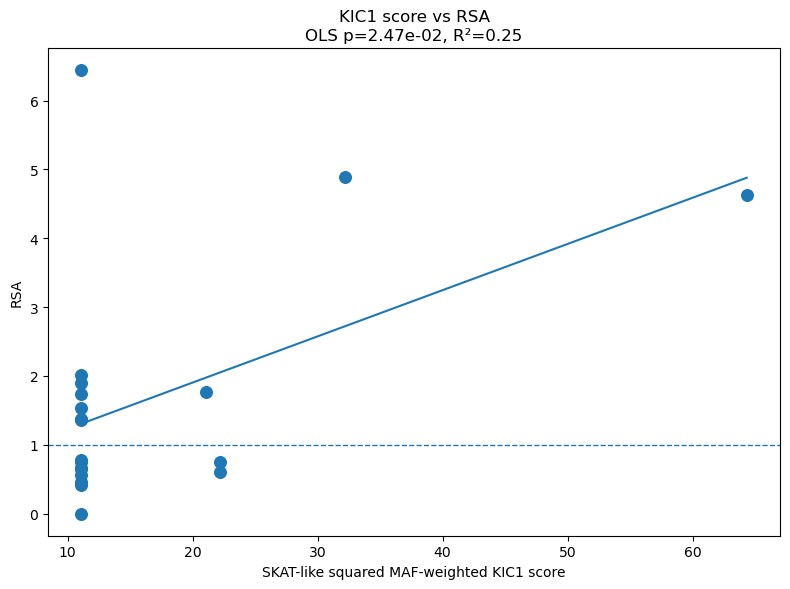

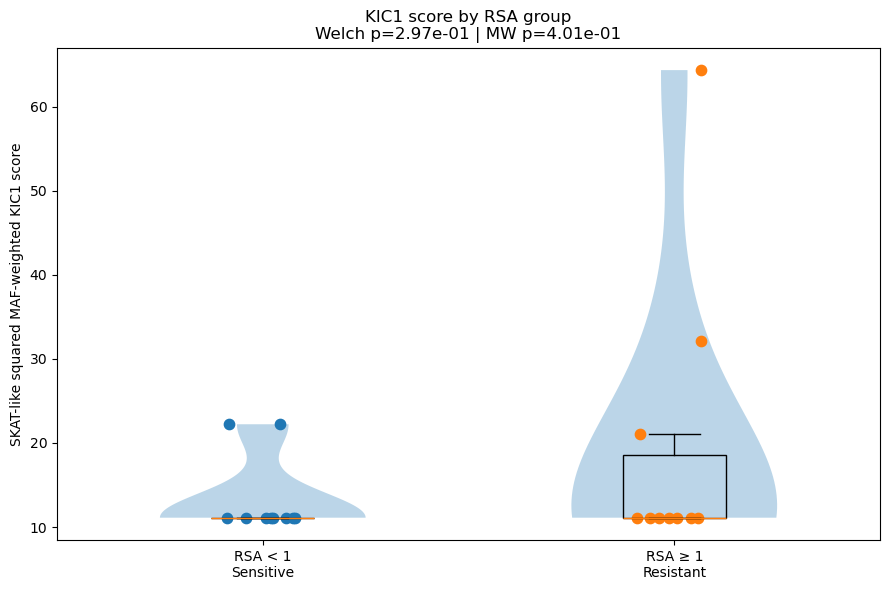

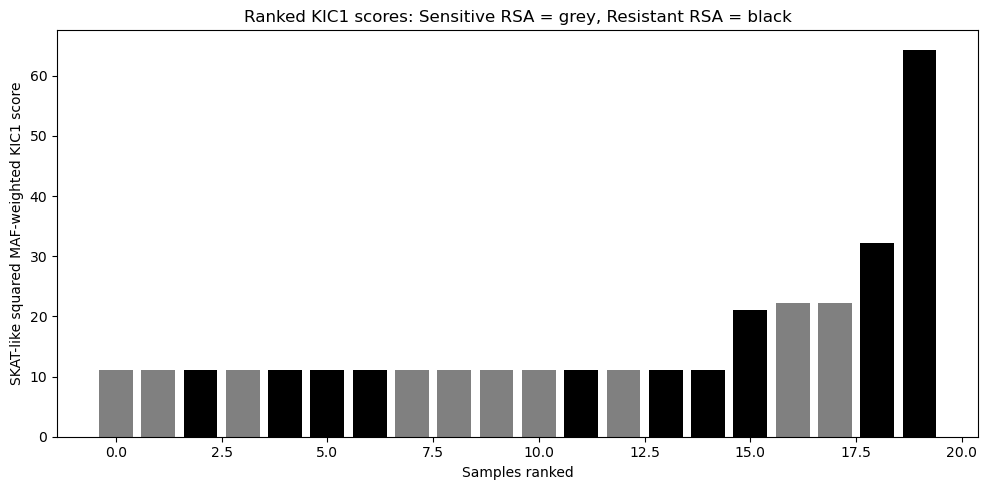


SNPs used in the KIC1 score:
Pf3D7_06_v3:249910:A>T | EFFECT: intergenic_region | REF: A | ALT: T
Pf3D7_06_v3:251284:C>G | EFFECT: missense_variant | REF: C | ALT: G
Pf3D7_06_v3:251742:T>A | EFFECT: missense_variant | REF: T | ALT: A
Pf3D7_06_v3:251778:T>C | EFFECT: missense_variant | REF: T | ALT: C
Pf3D7_06_v3:251809:A>C | EFFECT: missense_variant | REF: A | ALT: C
Pf3D7_06_v3:252876:C>A | EFFECT: missense_variant | REF: C | ALT: A
Pf3D7_06_v3:253113:T>C | EFFECT: missense_variant | REF: T | ALT: C


In [3]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, pearsonr, spearmanr, ranksums
from sklearn.preprocessing import StandardScaler

# ============================================================
# FILE
# ============================================================
geno = pd.read_csv("KIC_1_vcf_subset_BD - Sheet1.csv")
geno.columns = [str(c).strip() for c in geno.columns]

# ============================================================
# RSA VALUES
# RSA >= 1 = resistant
# RSA < 1 = sensitive
# ============================================================
rsa = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-003-clone", "I-004", "I-011", "I-016",
        "I-018", "I-020", "I-029", "I-026", "I-033",
        "I-039", "I-041", "I-040", "I-027", "O-024",
        "I-008", "I-002", "O-014", "O-009", "O-032",
        "O-038", "I-019"
    ],
    "RSA": [
        0.6635725467, 2.007394647, 0, 0.6057562733, 4.634666667,
        0.7466666667, 1.76, 6.443333333, 0.6533333333, 1.889666667,
        4.891666667, 1.358666667, 0.7466666667, 0.5593333333, 1.73,
        1.535666667, 2.563333333, 2.126666667, 0.42, 0.783,
        1.371666667, 0.4633333333
    ]
})

rsa["Sample"] = rsa["Sample"].astype(str).str.strip()
rsa["RSA"] = pd.to_numeric(rsa["RSA"], errors="coerce")
rsa = rsa.dropna()

rsa["Group"] = np.where(rsa["RSA"] >= 1, "Resistant_RSA", "Sensitive_RSA")
rsa["Binary"] = (rsa["RSA"] >= 1).astype(int)

print("RSA phenotype table:")
print(rsa.to_string(index=False))

print("\nRSA group counts:")
print(rsa["Group"].value_counts())

# ============================================================
# MATCH SAMPLES
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found in genotype file.")

format_idx = list(geno.columns).index("FORMAT")
samples = list(geno.columns[format_idx + 1:])
samples = [str(s).strip() for s in samples]

common = sorted(set(samples).intersection(set(rsa["Sample"])))

print("\nSamples in VCF:", len(samples))
print("Samples with RSA:", len(rsa))
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching sample names between genotype file and RSA table.")

rsa_data = rsa.set_index("Sample").loc[common]

# ============================================================
# SNP IDs
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", "."]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

# ============================================================
# PARSE EFFECT FROM ANN
# ============================================================
def get_effect(info):
    if pd.isna(info):
        return None

    for field in str(info).split(";"):
        if field.startswith("ANN="):
            ann = field[4:].split(",")[0]
            parts = ann.split("|")
            if len(parts) > 1:
                return parts[1]

    return None

geno["EFFECT"] = geno["INFO"].apply(get_effect)

# ============================================================
# KEEP RELEVANT SNPs
# ============================================================
keep = geno["EFFECT"].str.contains(
    "missense|stop_gained|intergenic",
    na=False
)

geno_filt = geno[keep].copy()

print("\nNumber of retained SNPs:", geno_filt.shape[0])
print("\nRetained SNPs:")
for s in geno_filt["SNP_ID"].tolist():
    print(" ", s)

A_filt = A[geno_filt["SNP_ID"]].copy()

# ============================================================
# SKAT-LIKE SQUARED MAF-WEIGHTED GENE SCORE
# ============================================================
maf = A_filt.mean(axis=0)

weights = 1 / np.sqrt(maf * (1 - maf))
weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

weighted_alt = A_filt * weights
gene_score = (weighted_alt ** 2).sum(axis=1)

df = pd.DataFrame({
    "Sample": gene_score.index,
    "Score": gene_score.values,
    "RSA": rsa_data.loc[gene_score.index, "RSA"].values,
    "Group": rsa_data.loc[gene_score.index, "Group"].values,
    "Binary": rsa_data.loc[gene_score.index, "Binary"].values
})

df = df.dropna(subset=["RSA", "Score"]).copy()

print("\nAnalysis dataframe:")
print(df.to_string(index=False))

print("\nMatched sensitive/resistant counts:")
print(df["Group"].value_counts())

if df["Score"].nunique() <= 1:
    raise ValueError("Score has no variation across samples.")

# ============================================================
# CONTINUOUS ASSOCIATION: RSA ~ SCORE
# ============================================================
X = sm.add_constant(df["Score"])
fit = sm.OLS(df["RSA"], X).fit()

pearson_r, pearson_p = pearsonr(df["Score"], df["RSA"])
spearman_r, spearman_p = spearmanr(df["Score"], df["RSA"])

# ============================================================
# GROUP TESTS
# ============================================================
sensitive = df[df["Group"] == "Sensitive_RSA"]["Score"]
resistant = df[df["Group"] == "Resistant_RSA"]["Score"]

welch_p = ttest_ind(sensitive, resistant, equal_var=False).pvalue
mw_p = mannwhitneyu(sensitive, resistant, alternative="two-sided").pvalue
wilcox_p = ranksums(sensitive, resistant).pvalue

# ============================================================
# LOGISTIC REGRESSION
# ============================================================
try:
    logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
    logit_beta = logit.params.iloc[1]
    logit_p = logit.pvalues.iloc[1]
    odds_ratio = np.exp(logit_beta)
except Exception as e:
    logit_beta = np.nan
    logit_p = np.nan
    odds_ratio = np.nan
    print("\nLogistic regression failed:", e)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 70)
print("SKAT-LIKE SQUARED MAF-WEIGHTED KIC1 SCORE USING RSA")
print("RSA >= 1 = Resistant; RSA < 1 = Sensitive")
print("=" * 70)

print("\nWeights:")
print(weights.to_string())

print("\nSquared weights:")
print((weights ** 2).to_string())

print("\n--- Continuous association: RSA ~ Score ---")
print(f"OLS beta = {fit.params.iloc[1]:.12f}")
print(f"OLS p = {fit.pvalues.iloc[1]:.12g}")
print(f"R^2 = {fit.rsquared:.12f}")
print(f"Pearson r = {pearson_r:.12f}, p = {pearson_p:.12g}")
print(f"Spearman rho = {spearman_r:.12f}, p = {spearman_p:.12g}")

print("\n--- Group tests: Sensitive RSA < 1 vs Resistant RSA >= 1 ---")
print(f"Welch t-test p = {welch_p:.12g}")
print(f"Mann-Whitney p = {mw_p:.12g}")
print(f"Wilcoxon rank-sum p = {wilcox_p:.12g}")

print("\n--- Logistic regression: Resistant RSA ~ Score ---")
print(f"Logistic beta = {logit_beta}")
print(f"Logistic p = {logit_p}")
print(f"Odds ratio = {odds_ratio}")

print("\n--- Group means ---")
print(f"Sensitive RSA mean score = {sensitive.mean():.12f}")
print(f"Resistant RSA mean score = {resistant.mean():.12f}")

print("\n--- Sample-level scores ---")
print(df.to_string(index=False))

# ============================================================
# PLOT 1: SCORE VS RSA WITH SAMPLE LABELS
# ============================================================
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["RSA"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(1, linestyle="--", linewidth=1)

for _, row in df.iterrows():
    plt.text(
        row["Score"] + 0.03,
        row["RSA"],
        row["Sample"],
        fontsize=7,
        alpha=0.8
    )

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("RSA")
plt.title(f"KIC1 score vs RSA\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: VIOLIN + BOX + POINTS + SAMPLE LABELS
# ============================================================
plt.figure(figsize=(9, 6))

plot_groups = [
    df[df["Group"] == "Sensitive_RSA"],
    df[df["Group"] == "Resistant_RSA"]
]

pos = [1, 2]

plt.violinplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    showextrema=False
)

bp = plt.boxplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, d in enumerate(plot_groups):
    x_center = pos[i]
    xj = np.full(len(d), x_center, dtype=float) + rng.uniform(-0.09, 0.09, len(d))
    yj = d["Score"].values
    labels = d["Sample"].values

    plt.scatter(xj, yj, s=55)

    for x, y, label in zip(xj, yj, labels):
        plt.text(
            x + 0.025,
            y,
            label,
            fontsize=7,
            alpha=0.85
        )

plt.xticks(pos, ["RSA < 1\nSensitive", "RSA ≥ 1\nResistant"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by RSA group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: RANKED BAR PLOT WITH SAMPLE NAMES
# ============================================================
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Sensitive_RSA" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.xticks(range(len(df_sorted)), df_sorted["Sample"], rotation=90)
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples")
plt.title("Ranked KIC1 scores: Sensitive RSA = grey, Resistant RSA = black")

plt.tight_layout()
plt.show()

# ============================================================
# PERMUTATION TEST
# ============================================================
obs_diff = resistant.mean() - sensitive.mean()

perm_diffs = []
rng = np.random.default_rng(1)

for _ in range(10000):
    shuffled = rng.permutation(df["Score"].values)
    perm_sensitive = shuffled[:len(sensitive)]
    perm_resistant = shuffled[len(sensitive):]
    perm_diffs.append(perm_resistant.mean() - perm_sensitive.mean())

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

print("\nPermutation p =", p_perm)

# ============================================================
# LOG-TRANSFORMED SCORE TEST
# ============================================================
df["Score_log"] = np.log1p(df["Score"])

sensitive_log = df[df["Group"] == "Sensitive_RSA"]["Score_log"]
resistant_log = df[df["Group"] == "Resistant_RSA"]["Score_log"]

print("\n--- Log-score group tests ---")
print("Welch p =", ttest_ind(sensitive_log, resistant_log, equal_var=False).pvalue)
print("Mann-Whitney p =", mannwhitneyu(sensitive_log, resistant_log, alternative="two-sided").pvalue)

# ============================================================
# STANDARDIZED LOGISTIC REGRESSION
# ============================================================
scaler = StandardScaler()
df["Score_z"] = scaler.fit_transform(df[["Score"]])

try:
    X_z = sm.add_constant(df["Score_z"])
    y_bin = df["Binary"]

    logit_z = sm.Logit(y_bin, X_z).fit(disp=0)

    print("\n" + "=" * 60)
    print("STANDARDIZED LOGISTIC REGRESSION")
    print("=" * 60)
    print("Coefficient =", logit_z.params["Score_z"])
    print("p-value =", logit_z.pvalues["Score_z"])
    print("Odds ratio =", np.exp(logit_z.params["Score_z"]))

    conf = logit_z.conf_int().loc["Score_z"]
    conf_odds = np.exp(conf)
    print("95% CI odds ratio =", tuple(conf_odds))

    print("\nFull summary:")
    print(logit_z.summary())

except Exception as e:
    print("\nStandardized logistic regression failed:", e)

# ============================================================
# PLOTTING BLOCK WITHOUT SAMPLE NAME LABELS
# ============================================================

# ------------------------------------------------------------
# PLOT 1: SCORE VS RSA, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["RSA"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(1, linestyle="--", linewidth=1)

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("RSA")
plt.title(f"KIC1 score vs RSA\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2: VIOLIN + BOX + POINTS, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

data = [sensitive.values, resistant.values]
pos = [1, 2]

plt.violinplot(data, positions=pos, showextrema=False)

bp = plt.boxplot(
    data,
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, arr in enumerate(data):
    xj = np.full(len(arr), pos[i], dtype=float) + rng.uniform(-0.09, 0.09, len(arr))
    plt.scatter(xj, arr, s=55)

plt.xticks(pos, ["RSA < 1\nSensitive", "RSA ≥ 1\nResistant"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by RSA group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3: RANKED BAR PLOT, NO SAMPLE NAMES ON BARS
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Sensitive_RSA" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples ranked")
plt.title("Ranked KIC1 scores: Sensitive RSA = grey, Resistant RSA = black")

plt.tight_layout()
plt.show()

print("\nSNPs used in the KIC1 score:")
for i, row in geno_filt.iterrows():
    print(
        row["SNP_ID"],
        "| EFFECT:",
        row["EFFECT"],
        "| REF:",
        row["REF"],
        "| ALT:",
        row["ALT"]
    )

RSA phenotype table:
     Sample      RSA         Group  Binary
I-001-clone 0.663573 Sensitive_RSA       0
I-003-clone 2.007395 Resistant_RSA       1
      I-004 0.000000 Sensitive_RSA       0
      I-011 0.605756 Sensitive_RSA       0
      I-016 4.634667 Resistant_RSA       1
      I-018 0.746667 Sensitive_RSA       0
      I-020 1.760000 Resistant_RSA       1
      I-029 6.443333 Resistant_RSA       1
      I-026 0.653333 Sensitive_RSA       0
      I-033 1.889667 Resistant_RSA       1
      I-039 4.891667 Resistant_RSA       1
      I-041 1.358667 Resistant_RSA       1
      I-040 0.746667 Sensitive_RSA       0
      I-027 0.559333 Sensitive_RSA       0
      O-024 1.730000 Resistant_RSA       1
      I-008 1.535667 Resistant_RSA       1
      I-002 2.563333 Resistant_RSA       1
      O-014 2.126667 Resistant_RSA       1
      O-009 0.420000 Sensitive_RSA       0
      O-032 0.783000 Sensitive_RSA       0
      O-038 1.371667 Resistant_RSA       1
      I-019 0.463333 Sensitive_RS

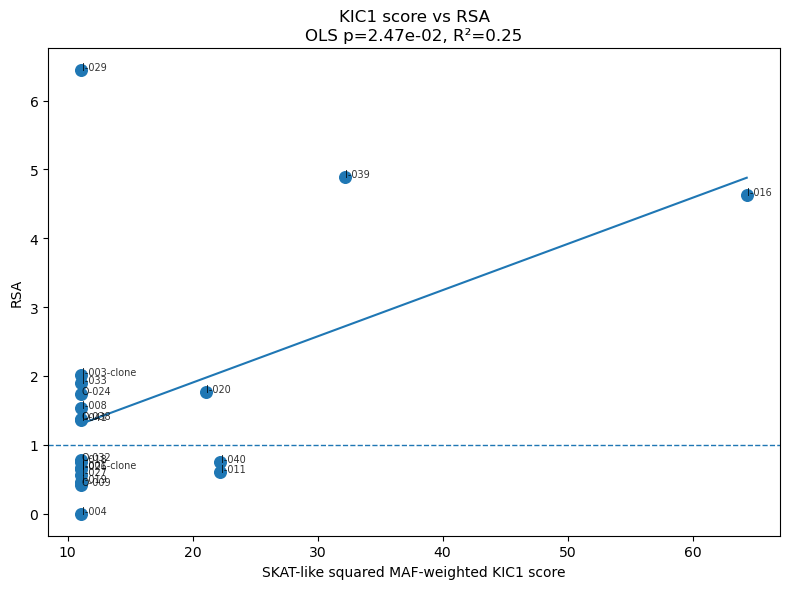

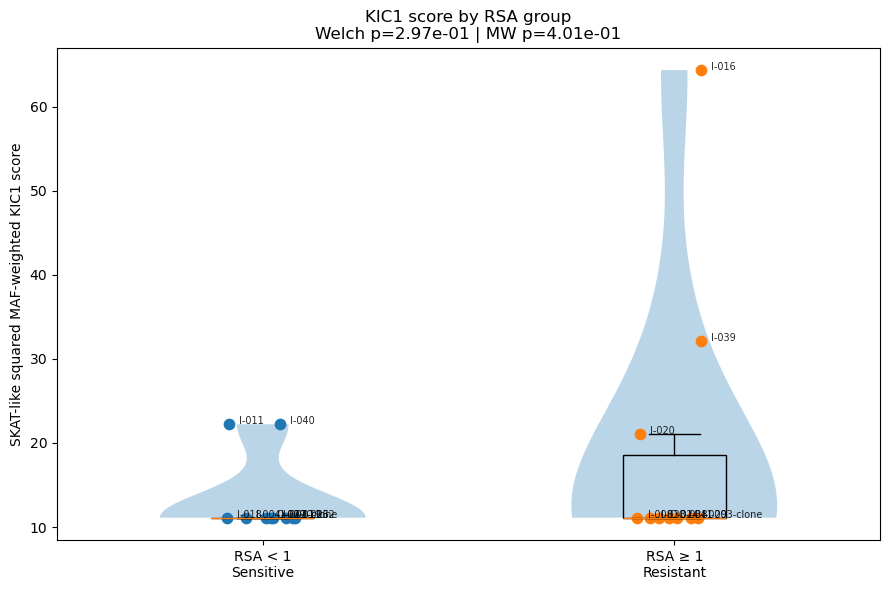

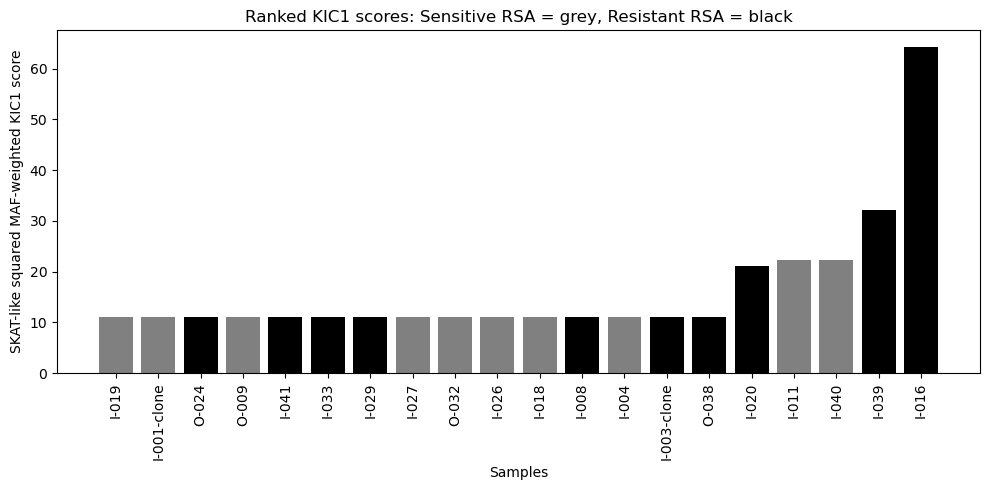


Permutation p = 0.4636

--- Log-score group tests ---
Welch p = 0.35138969281605337
Mann-Whitney p = 0.5845353391489482

STANDARDIZED LOGISTIC REGRESSION
Coefficient = 0.7017511308541103
p-value = 0.34054041496914655
Odds ratio = 2.0172821413174242
95% CI odds ratio = (0.4764751813238601, 8.54069088419576)

Full summary:
                           Logit Regression Results                           
Dep. Variable:                 Binary   No. Observations:                   20
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            1
Date:                Fri, 01 May 2026   Pseudo R-squ.:                 0.05291
Time:                        18:33:53   Log-Likelihood:                -13.129
converged:                       True   LL-Null:                       -13.863
Covariance Type:            nonrobust   LLR p-value:                    0.2258
                 coef    std err          z 

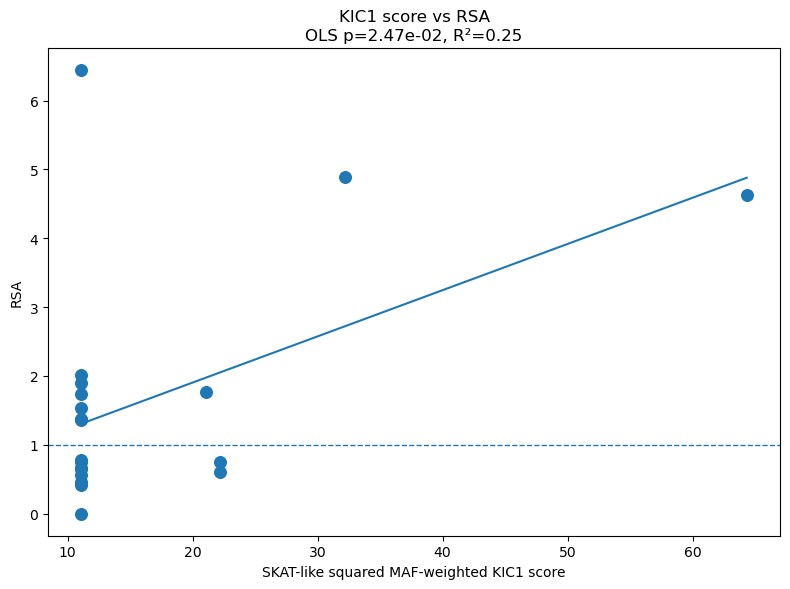

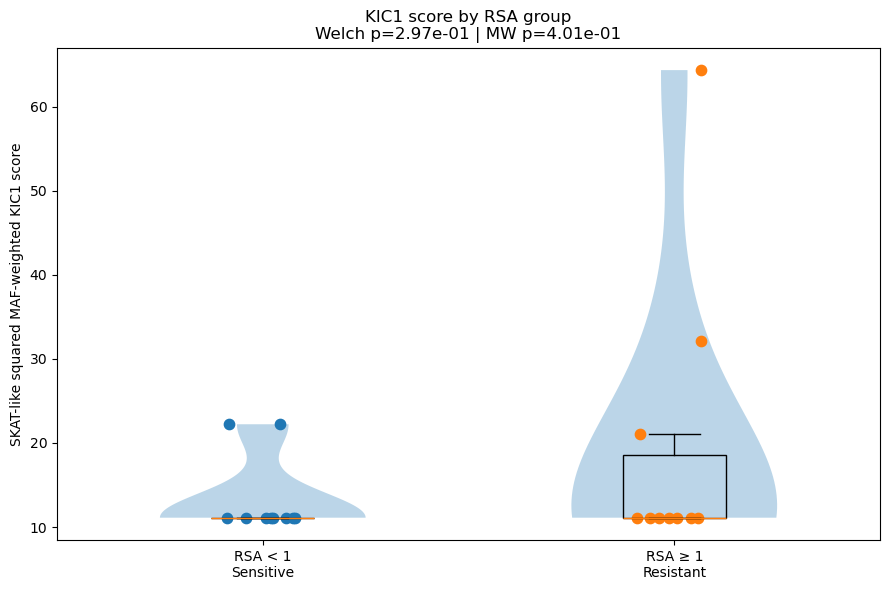

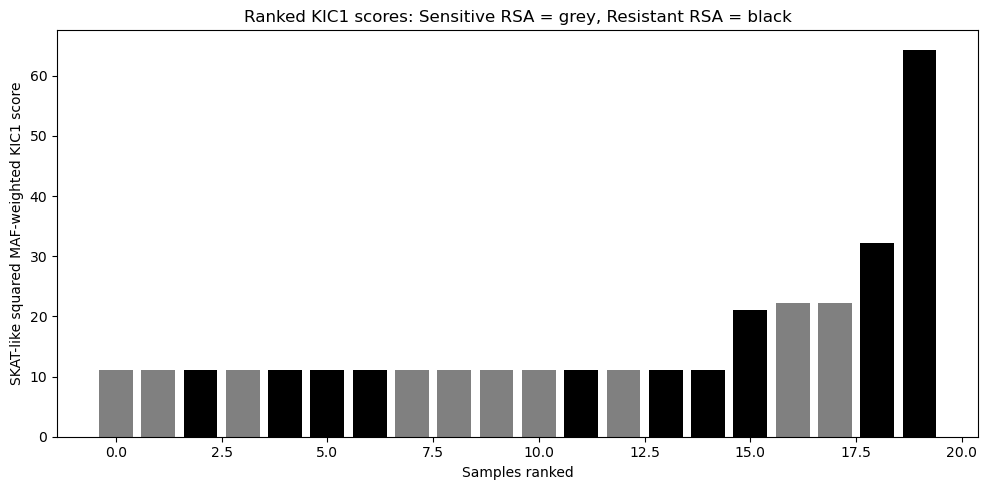


SNPs used in the KIC1 score:
Pf3D7_06_v3:249910:A>T | EFFECT: intergenic_region | REF: A | ALT: T
Pf3D7_06_v3:251284:C>G | EFFECT: missense_variant | REF: C | ALT: G
Pf3D7_06_v3:251742:T>A | EFFECT: missense_variant | REF: T | ALT: A
Pf3D7_06_v3:251778:T>C | EFFECT: missense_variant | REF: T | ALT: C
Pf3D7_06_v3:251809:A>C | EFFECT: missense_variant | REF: A | ALT: C
Pf3D7_06_v3:252876:C>A | EFFECT: missense_variant | REF: C | ALT: A
Pf3D7_06_v3:253113:T>C | EFFECT: missense_variant | REF: T | ALT: C

PENALIZED REGRESSION (ELASTIC NET) ON KIC1 PER-SNP FEATURES — RSA
Design matrix shape: (20, 7)
Features (SNPs):     7
Samples:             20

--- Selected hyperparameters (LOOCV) ---
Optimal lambda (sklearn alpha): 0.241417
Optimal mixing l1_ratio:        0.50

--- Final coefficients (RSA ~ weighted SNPs) ---
                SNP_ID  MB_weight  Coefficient  Selected
Pf3D7_06_v3:249910:A>T   4.588315     0.568466      True
Pf3D7_06_v3:251284:C>G   3.333333     0.000000     False
Pf3D7_06_

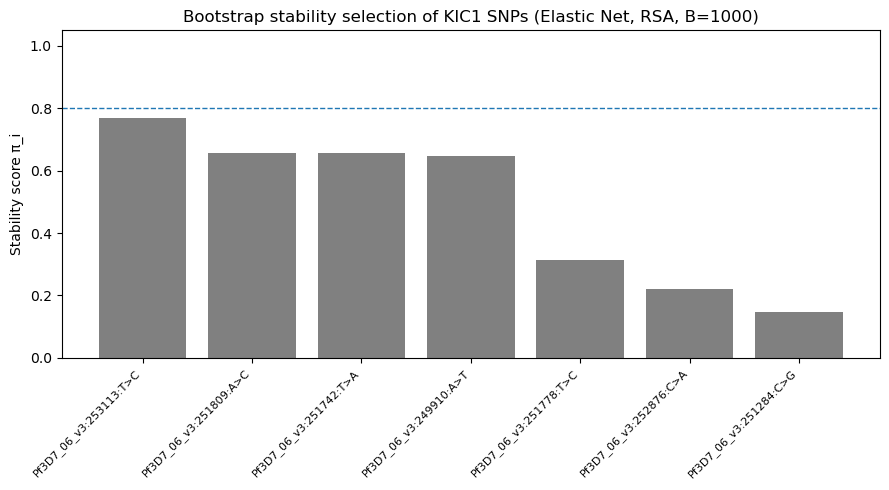

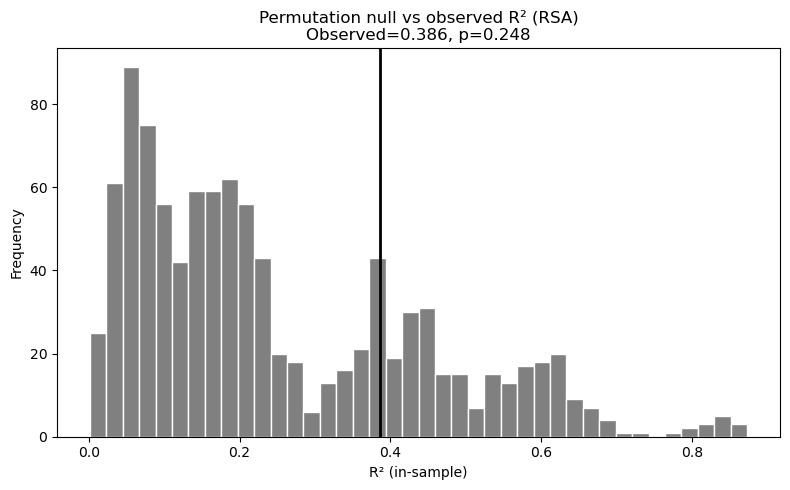

In [8]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, pearsonr, spearmanr, ranksums
from sklearn.preprocessing import StandardScaler

# ============================================================
# FILE
# ============================================================
geno = pd.read_csv("KIC_1_vcf_subset_BD - Sheet1.csv")
geno.columns = [str(c).strip() for c in geno.columns]

# ============================================================
# RSA VALUES
# RSA >= 1 = resistant
# RSA < 1 = sensitive
# ============================================================
rsa = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-003-clone", "I-004", "I-011", "I-016",
        "I-018", "I-020", "I-029", "I-026", "I-033",
        "I-039", "I-041", "I-040", "I-027", "O-024",
        "I-008", "I-002", "O-014", "O-009", "O-032",
        "O-038", "I-019"
    ],
    "RSA": [
        0.6635725467, 2.007394647, 0, 0.6057562733, 4.634666667,
        0.7466666667, 1.76, 6.443333333, 0.6533333333, 1.889666667,
        4.891666667, 1.358666667, 0.7466666667, 0.5593333333, 1.73,
        1.535666667, 2.563333333, 2.126666667, 0.42, 0.783,
        1.371666667, 0.4633333333
    ]
})

rsa["Sample"] = rsa["Sample"].astype(str).str.strip()
rsa["RSA"] = pd.to_numeric(rsa["RSA"], errors="coerce")
rsa = rsa.dropna()

rsa["Group"] = np.where(rsa["RSA"] >= 1, "Resistant_RSA", "Sensitive_RSA")
rsa["Binary"] = (rsa["RSA"] >= 1).astype(int)

print("RSA phenotype table:")
print(rsa.to_string(index=False))

print("\nRSA group counts:")
print(rsa["Group"].value_counts())

# ============================================================
# MATCH SAMPLES
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found in genotype file.")

format_idx = list(geno.columns).index("FORMAT")
samples = list(geno.columns[format_idx + 1:])
samples = [str(s).strip() for s in samples]

common = sorted(set(samples).intersection(set(rsa["Sample"])))

print("\nSamples in VCF:", len(samples))
print("Samples with RSA:", len(rsa))
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching sample names between genotype file and RSA table.")

rsa_data = rsa.set_index("Sample").loc[common]

# ============================================================
# SNP IDs
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", "."]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

# ============================================================
# PARSE EFFECT FROM ANN
# ============================================================
def get_effect(info):
    if pd.isna(info):
        return None

    for field in str(info).split(";"):
        if field.startswith("ANN="):
            ann = field[4:].split(",")[0]
            parts = ann.split("|")
            if len(parts) > 1:
                return parts[1]

    return None

geno["EFFECT"] = geno["INFO"].apply(get_effect)

# ============================================================
# KEEP RELEVANT SNPs
# ============================================================
keep = geno["EFFECT"].str.contains(
    "missense|stop_gained|intergenic",
    na=False
)

geno_filt = geno[keep].copy()

print("\nNumber of retained SNPs:", geno_filt.shape[0])
print("\nRetained SNPs:")
for s in geno_filt["SNP_ID"].tolist():
    print(" ", s)

A_filt = A[geno_filt["SNP_ID"]].copy()

# ============================================================
# SKAT-LIKE SQUARED MAF-WEIGHTED GENE SCORE
# ============================================================
maf = A_filt.mean(axis=0)

weights = 1 / np.sqrt(maf * (1 - maf))
weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

weighted_alt = A_filt * weights
gene_score = (weighted_alt ** 2).sum(axis=1)

df = pd.DataFrame({
    "Sample": gene_score.index,
    "Score": gene_score.values,
    "RSA": rsa_data.loc[gene_score.index, "RSA"].values,
    "Group": rsa_data.loc[gene_score.index, "Group"].values,
    "Binary": rsa_data.loc[gene_score.index, "Binary"].values
})

df = df.dropna(subset=["RSA", "Score"]).copy()

print("\nAnalysis dataframe:")
print(df.to_string(index=False))

print("\nMatched sensitive/resistant counts:")
print(df["Group"].value_counts())

if df["Score"].nunique() <= 1:
    raise ValueError("Score has no variation across samples.")

# ============================================================
# CONTINUOUS ASSOCIATION: RSA ~ SCORE
# ============================================================
X = sm.add_constant(df["Score"])
fit = sm.OLS(df["RSA"], X).fit()

pearson_r, pearson_p = pearsonr(df["Score"], df["RSA"])
spearman_r, spearman_p = spearmanr(df["Score"], df["RSA"])

# ============================================================
# GROUP TESTS
# ============================================================
sensitive = df[df["Group"] == "Sensitive_RSA"]["Score"]
resistant = df[df["Group"] == "Resistant_RSA"]["Score"]

welch_p = ttest_ind(sensitive, resistant, equal_var=False).pvalue
mw_p = mannwhitneyu(sensitive, resistant, alternative="two-sided").pvalue
wilcox_p = ranksums(sensitive, resistant).pvalue

# ============================================================
# LOGISTIC REGRESSION
# ============================================================
try:
    logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
    logit_beta = logit.params.iloc[1]
    logit_p = logit.pvalues.iloc[1]
    odds_ratio = np.exp(logit_beta)
except Exception as e:
    logit_beta = np.nan
    logit_p = np.nan
    odds_ratio = np.nan
    print("\nLogistic regression failed:", e)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 70)
print("SKAT-LIKE SQUARED MAF-WEIGHTED KIC1 SCORE USING RSA")
print("RSA >= 1 = Resistant; RSA < 1 = Sensitive")
print("=" * 70)

print("\nWeights:")
print(weights.to_string())

print("\nSquared weights:")
print((weights ** 2).to_string())

print("\n--- Continuous association: RSA ~ Score ---")
print(f"OLS beta = {fit.params.iloc[1]:.12f}")
print(f"OLS p = {fit.pvalues.iloc[1]:.12g}")
print(f"R^2 = {fit.rsquared:.12f}")
print(f"Pearson r = {pearson_r:.12f}, p = {pearson_p:.12g}")
print(f"Spearman rho = {spearman_r:.12f}, p = {spearman_p:.12g}")

print("\n--- Group tests: Sensitive RSA < 1 vs Resistant RSA >= 1 ---")
print(f"Welch t-test p = {welch_p:.12g}")
print(f"Mann-Whitney p = {mw_p:.12g}")
print(f"Wilcoxon rank-sum p = {wilcox_p:.12g}")

print("\n--- Logistic regression: Resistant RSA ~ Score ---")
print(f"Logistic beta = {logit_beta}")
print(f"Logistic p = {logit_p}")
print(f"Odds ratio = {odds_ratio}")

print("\n--- Group means ---")
print(f"Sensitive RSA mean score = {sensitive.mean():.12f}")
print(f"Resistant RSA mean score = {resistant.mean():.12f}")

print("\n--- Sample-level scores ---")
print(df.to_string(index=False))

# ============================================================
# PLOT 1: SCORE VS RSA WITH SAMPLE LABELS
# ============================================================
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["RSA"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(1, linestyle="--", linewidth=1)

for _, row in df.iterrows():
    plt.text(
        row["Score"] + 0.03,
        row["RSA"],
        row["Sample"],
        fontsize=7,
        alpha=0.8
    )

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("RSA")
plt.title(f"KIC1 score vs RSA\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: VIOLIN + BOX + POINTS + SAMPLE LABELS
# ============================================================
plt.figure(figsize=(9, 6))

plot_groups = [
    df[df["Group"] == "Sensitive_RSA"],
    df[df["Group"] == "Resistant_RSA"]
]

pos = [1, 2]

plt.violinplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    showextrema=False
)

bp = plt.boxplot(
    [d["Score"] for d in plot_groups],
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, d in enumerate(plot_groups):
    x_center = pos[i]
    xj = np.full(len(d), x_center, dtype=float) + rng.uniform(-0.09, 0.09, len(d))
    yj = d["Score"].values
    labels = d["Sample"].values

    plt.scatter(xj, yj, s=55)

    for x, y, label in zip(xj, yj, labels):
        plt.text(
            x + 0.025,
            y,
            label,
            fontsize=7,
            alpha=0.85
        )

plt.xticks(pos, ["RSA < 1\nSensitive", "RSA ≥ 1\nResistant"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by RSA group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: RANKED BAR PLOT WITH SAMPLE NAMES
# ============================================================
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Sensitive_RSA" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.xticks(range(len(df_sorted)), df_sorted["Sample"], rotation=90)
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples")
plt.title("Ranked KIC1 scores: Sensitive RSA = grey, Resistant RSA = black")

plt.tight_layout()
plt.show()

# ============================================================
# PERMUTATION TEST
# ============================================================
obs_diff = resistant.mean() - sensitive.mean()

perm_diffs = []
rng = np.random.default_rng(1)

for _ in range(10000):
    shuffled = rng.permutation(df["Score"].values)
    perm_sensitive = shuffled[:len(sensitive)]
    perm_resistant = shuffled[len(sensitive):]
    perm_diffs.append(perm_resistant.mean() - perm_sensitive.mean())

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

print("\nPermutation p =", p_perm)

# ============================================================
# LOG-TRANSFORMED SCORE TEST
# ============================================================
df["Score_log"] = np.log1p(df["Score"])

sensitive_log = df[df["Group"] == "Sensitive_RSA"]["Score_log"]
resistant_log = df[df["Group"] == "Resistant_RSA"]["Score_log"]

print("\n--- Log-score group tests ---")
print("Welch p =", ttest_ind(sensitive_log, resistant_log, equal_var=False).pvalue)
print("Mann-Whitney p =", mannwhitneyu(sensitive_log, resistant_log, alternative="two-sided").pvalue)

# ============================================================
# STANDARDIZED LOGISTIC REGRESSION
# ============================================================
scaler = StandardScaler()
df["Score_z"] = scaler.fit_transform(df[["Score"]])

try:
    X_z = sm.add_constant(df["Score_z"])
    y_bin = df["Binary"]

    logit_z = sm.Logit(y_bin, X_z).fit(disp=0)

    print("\n" + "=" * 60)
    print("STANDARDIZED LOGISTIC REGRESSION")
    print("=" * 60)
    print("Coefficient =", logit_z.params["Score_z"])
    print("p-value =", logit_z.pvalues["Score_z"])
    print("Odds ratio =", np.exp(logit_z.params["Score_z"]))

    conf = logit_z.conf_int().loc["Score_z"]
    conf_odds = np.exp(conf)
    print("95% CI odds ratio =", tuple(conf_odds))

    print("\nFull summary:")
    print(logit_z.summary())

except Exception as e:
    print("\nStandardized logistic regression failed:", e)

# ============================================================
# PLOTTING BLOCK WITHOUT SAMPLE NAME LABELS
# ============================================================

# ------------------------------------------------------------
# PLOT 1: SCORE VS RSA, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(df["Score"], df["RSA"], s=70)

xline = np.linspace(df["Score"].min(), df["Score"].max(), 100)
yline = fit.params.iloc[0] + fit.params.iloc[1] * xline
plt.plot(xline, yline)

plt.axhline(1, linestyle="--", linewidth=1)

plt.xlabel("SKAT-like squared MAF-weighted KIC1 score")
plt.ylabel("RSA")
plt.title(f"KIC1 score vs RSA\nOLS p={fit.pvalues.iloc[1]:.2e}, R²={fit.rsquared:.2f}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2: VIOLIN + BOX + POINTS, NO LABELS
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))

data = [sensitive.values, resistant.values]
pos = [1, 2]

plt.violinplot(data, positions=pos, showextrema=False)

bp = plt.boxplot(
    data,
    positions=pos,
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

for b in bp["boxes"]:
    b.set_facecolor("none")

rng = np.random.default_rng(0)

for i, arr in enumerate(data):
    xj = np.full(len(arr), pos[i], dtype=float) + rng.uniform(-0.09, 0.09, len(arr))
    plt.scatter(xj, arr, s=55)

plt.xticks(pos, ["RSA < 1\nSensitive", "RSA ≥ 1\nResistant"])
plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.title(f"KIC1 score by RSA group\nWelch p={welch_p:.2e} | MW p={mw_p:.2e}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3: RANKED BAR PLOT, NO SAMPLE NAMES ON BARS
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

df_sorted = df.sort_values("Score").reset_index(drop=True)
colors = ["grey" if g == "Sensitive_RSA" else "black" for g in df_sorted["Group"]]

plt.bar(range(len(df_sorted)), df_sorted["Score"], color=colors)

plt.ylabel("SKAT-like squared MAF-weighted KIC1 score")
plt.xlabel("Samples ranked")
plt.title("Ranked KIC1 scores: Sensitive RSA = grey, Resistant RSA = black")

plt.tight_layout()
plt.show()

print("\nSNPs used in the KIC1 score:")
for i, row in geno_filt.iterrows():
    print(
        row["SNP_ID"],
        "| EFFECT:",
        row["EFFECT"],
        "| REF:",
        row["REF"],
        "| ALT:",
        row["ALT"]
    )


# ============================================================
# PENALIZED REGRESSION EXTENSION — RSA PHENOTYPE
# Append this block to your existing KIC1 RSA analysis script.
# Requires: A_filt, weights, df (already constructed above)
# df must contain columns: Sample, Score, RSA, Group, Binary
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# STEP 1: Construct the weighted per-SNP feature matrix
# A_tilde_{ji} = w_i * A_{ji}
# Shape: (n_samples, m_snps)
# ------------------------------------------------------------
A_tilde = A_filt.multiply(weights, axis=1)
A_tilde = A_tilde.loc[df["Sample"].values]   # align row order to df

X_ml = A_tilde.values                         # design matrix
y_ml = df["RSA"].values                       # continuous outcome (RSA)
snp_names = A_tilde.columns.tolist()

print("\n" + "=" * 70)
print("PENALIZED REGRESSION (ELASTIC NET) ON KIC1 PER-SNP FEATURES — RSA")
print("=" * 70)
print(f"Design matrix shape: {X_ml.shape}")
print(f"Features (SNPs):     {len(snp_names)}")
print(f"Samples:             {X_ml.shape[0]}")

# ------------------------------------------------------------
# STEP 2 + 3: Elastic net with LOOCV over (alpha, l1_ratio)
# sklearn parameterization:
#   alpha       <-> lambda  (penalty strength)
#   l1_ratio    <-> alpha   (mixing: 1 = lasso, 0 = ridge)
# ------------------------------------------------------------
loo = LeaveOneOut()
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

enet_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    n_alphas=100,
    cv=loo,
    max_iter=20000,
    fit_intercept=True,
    random_state=0,
)

enet_cv.fit(X_ml, y_ml)

print("\n--- Selected hyperparameters (LOOCV) ---")
print(f"Optimal lambda (sklearn alpha): {enet_cv.alpha_:.6f}")
print(f"Optimal mixing l1_ratio:        {enet_cv.l1_ratio_:.2f}")

# ------------------------------------------------------------
# Refit at the optimal hyperparameters on full data
# ------------------------------------------------------------
enet_final = ElasticNet(
    alpha=enet_cv.alpha_,
    l1_ratio=enet_cv.l1_ratio_,
    max_iter=20000,
    fit_intercept=True,
)
enet_final.fit(X_ml, y_ml)

coef_table = pd.DataFrame({
    "SNP_ID": snp_names,
    "MB_weight": weights[snp_names].values,
    "Coefficient": enet_final.coef_,
    "Selected": enet_final.coef_ != 0,
})

print("\n--- Final coefficients (RSA ~ weighted SNPs) ---")
print(coef_table.to_string(index=False))
print(f"\nNumber of SNPs with non-zero coefficient: "
      f"{int(coef_table['Selected'].sum())} / {len(snp_names)}")

# ------------------------------------------------------------
# STEP 4: Bootstrap stability selection
# pi_i = fraction of bootstrap resamples where SNP i is selected
# ------------------------------------------------------------
B = 1000
rng_boot = np.random.default_rng(42)
n_samples = X_ml.shape[0]
selection_matrix = np.zeros((B, len(snp_names)), dtype=int)

for b in range(B):
    idx = rng_boot.choice(n_samples, size=n_samples, replace=True)
    X_b, y_b = X_ml[idx], y_ml[idx]
    try:
        model_b = ElasticNet(
            alpha=enet_cv.alpha_,
            l1_ratio=enet_cv.l1_ratio_,
            max_iter=20000,
            fit_intercept=True,
        )
        model_b.fit(X_b, y_b)
        selection_matrix[b] = (model_b.coef_ != 0).astype(int)
    except Exception:
        selection_matrix[b] = 0

stability = selection_matrix.mean(axis=0)

stability_table = pd.DataFrame({
    "SNP_ID": snp_names,
    "MB_weight": weights[snp_names].values,
    "Final_coef": enet_final.coef_,
    "Stability_pi": stability,
    "Robust_pi>=0.8": stability >= 0.8,
}).sort_values("Stability_pi", ascending=False)

print("\n--- Stability selection (B = 1000 bootstrap resamples) ---")
print(stability_table.to_string(index=False))

# ------------------------------------------------------------
# STEP 5: Permutation test on full-model R^2
# ------------------------------------------------------------
y_pred_obs = enet_final.predict(X_ml)
r2_obs = r2_score(y_ml, y_pred_obs)

n_perm = 1000
rng_perm = np.random.default_rng(7)
r2_null = np.zeros(n_perm)

for b in range(n_perm):
    y_perm = rng_perm.permutation(y_ml)
    model_p = ElasticNet(
        alpha=enet_cv.alpha_,
        l1_ratio=enet_cv.l1_ratio_,
        max_iter=20000,
        fit_intercept=True,
    )
    model_p.fit(X_ml, y_perm)
    r2_null[b] = r2_score(y_perm, model_p.predict(X_ml))

p_perm_r2 = (1 + np.sum(r2_null >= r2_obs)) / (1 + n_perm)

print("\n--- Permutation test of model R^2 (RSA) ---")
print(f"Observed in-sample R^2: {r2_obs:.4f}")
print(f"Null R^2 mean:          {r2_null.mean():.4f}")
print(f"Null R^2 95th pct:      {np.quantile(r2_null, 0.95):.4f}")
print(f"Permutation p-value:    {p_perm_r2:.4f}")

# ------------------------------------------------------------
# PLOT: Stability scores per SNP
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
order = np.argsort(stability)[::-1]
plt.bar(range(len(snp_names)),
        stability[order],
        color=["black" if stability[i] >= 0.8 else "grey" for i in order])
plt.axhline(0.8, linestyle="--", linewidth=1)
plt.xticks(range(len(snp_names)),
           [snp_names[i] for i in order],
           rotation=45, ha="right", fontsize=8)
plt.ylabel("Stability score π_i")
plt.ylim(0, 1.05)
plt.title("Bootstrap stability selection of KIC1 SNPs (Elastic Net, RSA, B=1000)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT: Observed vs null R^2 distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(r2_null, bins=40, color="grey", edgecolor="white")
plt.axvline(r2_obs, color="black", linewidth=2)
plt.xlabel("R² (in-sample)")
plt.ylabel("Frequency")
plt.title(f"Permutation null vs observed R² (RSA)\nObserved={r2_obs:.3f}, p={p_perm_r2:.3f}")
plt.tight_layout()
plt.show()

Genomewide association using RSA

Using file: ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv

RSA group counts:
Group
Resistant_RSA    12
Sensitive_RSA    10
Name: count, dtype: int64

Samples in VCF: 20
Samples with RSA: 22
Matched samples: 20
['I-001-clone', 'I-003-clone', 'I-004', 'I-008', 'I-011', 'I-016', 'I-018', 'I-019', 'I-020', 'I-026', 'I-027', 'I-029', 'I-033', 'I-039', 'I-040', 'I-041', 'O-009', 'O-024', 'O-032', 'O-038']

ALT matrix shape: (20, 39006)

Dropped synonymous ANN records: 7769
Gene-body/transcript non-synonymous assignments: 23960
Raw intergenic SNP records: 10283

Observed gene intervals built for genes: 3874

Intergenic SNPs assigned after closest-gene 50 kb filter: 9617

Intergenic distance summary:
count    9617.000000
mean     1369.398357
std      1125.673237
min         1.000000
25%       629.000000
50%      1100.000000
75%      1747.000000
max      9543.000000
Name: Distance_to_gene_bp, dtype: float64

Total SNP-to-gene assignments after dropping synonymous: 32383
Unique SNPs assigned: 30876
Uni

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/nirjharbhat


Number of tested genes: 1970
Result columns: ['Gene_ID', 'CHROM', 'Gene_mid_POS', 'Min_POS', 'Max_POS', 'N_SNPs_used', 'N_intergenic_SNP_assignments_50kb', 'N_gene_body_or_transcript_SNP_assignments', 'Max_intergenic_distance_bp', 'Mean_intergenic_distance_bp', 'SNPs_used', 'Effects_used', 'Mean_score_sensitive_RSA_lt_1', 'Mean_score_resistant_RSA_ge_1', 'Difference_resistant_minus_sensitive', 'OLS_beta_RSA', 'OLS_p_RSA', 'OLS_R2_RSA', 'Welch_p', 'MannWhitney_p', 'Wilcoxon_rank_sum_p', 'Logistic_beta', 'Logistic_p', 'Logistic_OR']

Top 30 genome-wide gene results:
      Gene_ID  Common_name       CHROM  Gene_mid_POS  Min_POS  Max_POS  N_SNPs_used  N_intergenic_SNP_assignments_50kb  N_gene_body_or_transcript_SNP_assignments  Max_intergenic_distance_bp  Mean_intergenic_distance_bp                                                                        Effects_used  Mean_score_sensitive_RSA_lt_1  Mean_score_resistant_RSA_ge_1  Difference_resistant_minus_sensitive  OLS_beta_RSA  OLS_p_RSA 

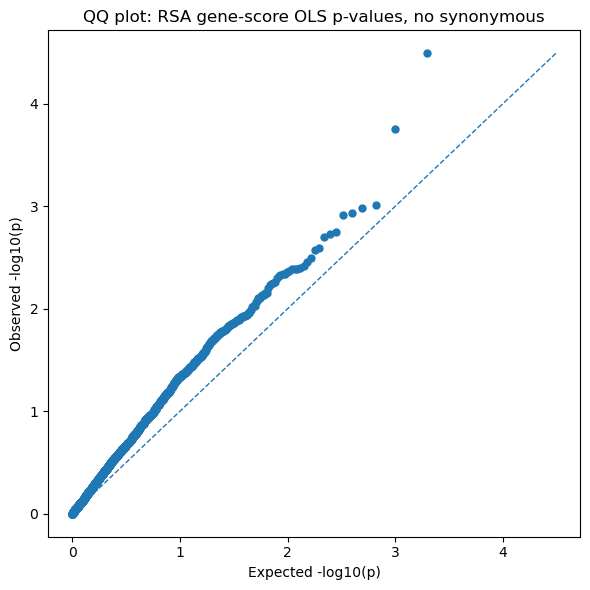


Rows before Manhattan chromosome filtering: 1970
          Gene_ID        CHROM  CHR_NUM  Gene_mid_POS  OLS_p_RSA
0   PF3D7_1434300  Pf3D7_14_v3       14     1374375.0   0.000032
1   PF3D7_1462500  Pf3D7_14_v3       14     2546699.0   0.000177
2   PF3D7_1133700  Pf3D7_11_v3       11     1305088.0   0.000981
3   PF3D7_1457400  Pf3D7_14_v3       14     2355364.5   0.001049
4   PF3D7_1356200  Pf3D7_13_v3       13     2228893.0   0.001165
5   PF3D7_1321500  Pf3D7_13_v3       13      893513.0   0.001218
6   PF3D7_1019300  Pf3D7_10_v3       10      780126.0   0.001802
7   PF3D7_1134500  Pf3D7_11_v3       11     1345723.0   0.001860
8   PF3D7_1436200  Pf3D7_14_v3       14     1470962.0   0.002025
9   PF3D7_1007800  Pf3D7_10_v3       10      313832.0   0.002589
10  PF3D7_0602700  Pf3D7_06_v3        6      113699.0   0.002679
11  PF3D7_1428500  Pf3D7_14_v3       14     1123871.0   0.003188
12  PF3D7_0214400  Pf3D7_02_v3        2      589209.5   0.003497
13  PF3D7_0106700  Pf3D7_01_v3        1 

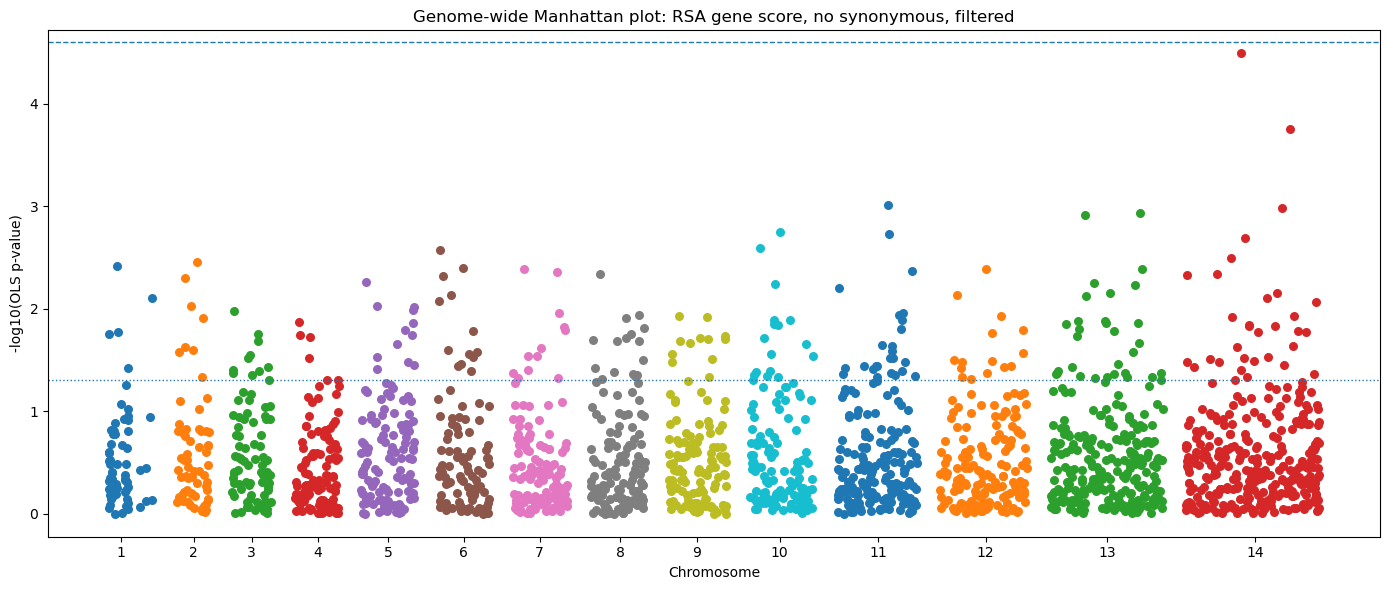

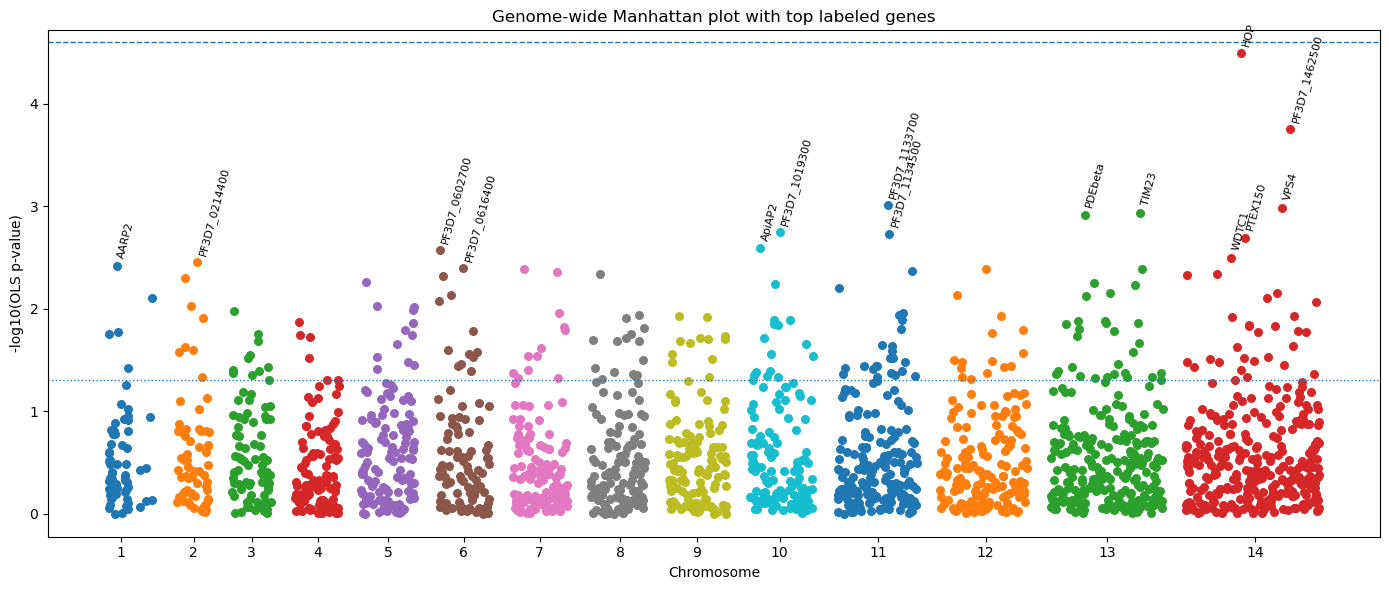


Examples of closest intergenic SNP assignments within 50 kb:
                SNP_ID       Gene_ID Common_name  Distance_to_gene_bp            Effect
Pf3D7_02_v3:106230:T>G PF3D7_0202100       LSAP2               3525.0 intergenic_region
Pf3D7_02_v3:109073:G>C PF3D7_0202100       LSAP2                682.0 intergenic_region
Pf3D7_02_v3:109248:C>G PF3D7_0202100       LSAP2                507.0 intergenic_region
Pf3D7_02_v3:112093:G>A PF3D7_0202100       LSAP2               2048.0 intergenic_region
Pf3D7_02_v3:119335:A>C PF3D7_0202400                           1567.0 intergenic_region
Pf3D7_02_v3:119979:C>A PF3D7_0202400                            923.0 intergenic_region
Pf3D7_02_v3:120002:A>C PF3D7_0202400                            900.0 intergenic_region
Pf3D7_02_v3:120086:A>T PF3D7_0202400                            816.0 intergenic_region
Pf3D7_02_v3:120161:A>T PF3D7_0202400                            741.0 intergenic_region
Pf3D7_02_v3:120248:G>A PF3D7_0202400                      

In [4]:
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, ranksums
from statsmodels.stats.multitest import multipletests

# ============================================================
# FILE
# ============================================================
possible_files = [
    "ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv",
    "ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1(2).csv",
    "/mnt/data/ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv",
    "/mnt/data/ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1(2).csv"
]

vcf_csv = None
for f in possible_files:
    if os.path.exists(f):
        vcf_csv = f
        break

if vcf_csv is None:
    raise FileNotFoundError("VCF CSV file not found.")

print("Using file:", vcf_csv)

geno = pd.read_csv(vcf_csv, low_memory=False)
geno.columns = [str(c).strip() for c in geno.columns]

# ============================================================
# PARAMETERS
# ============================================================
MAX_DIST = 50_000
MIN_SNPS_PER_GENE = 2

MIN_ALT_COUNT = 2
MIN_REF_COUNT = 2
MIN_UNIQUE_SCORES = 3
MIN_SCORE_SD = 1e-6

# ============================================================
# RSA PHENOTYPE
# RSA >= 1 = resistant
# RSA < 1 = sensitive
# ============================================================
rsa = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-003-clone", "I-004", "I-011", "I-016",
        "I-018", "I-020", "I-029", "I-026", "I-033",
        "I-039", "I-041", "I-040", "I-027", "O-024",
        "I-008", "I-002", "O-014", "O-009", "O-032",
        "O-038", "I-019"
    ],
    "RSA": [
        0.6635725467, 2.007394647, 0, 0.6057562733, 4.634666667,
        0.7466666667, 1.76, 6.443333333, 0.6533333333, 1.889666667,
        4.891666667, 1.358666667, 0.7466666667, 0.5593333333, 1.73,
        1.535666667, 2.563333333, 2.126666667, 0.42, 0.783,
        1.371666667, 0.4633333333
    ]
})

rsa["Sample"] = rsa["Sample"].astype(str).str.strip()
rsa["RSA"] = pd.to_numeric(rsa["RSA"], errors="coerce")
rsa = rsa.dropna()

rsa["Binary"] = (rsa["RSA"] >= 1).astype(int)
rsa["Group"] = np.where(rsa["RSA"] >= 1, "Resistant_RSA", "Sensitive_RSA")
rsa = rsa.set_index("Sample")

print("\nRSA group counts:")
print(rsa["Group"].value_counts())

# ============================================================
# SAMPLE MATCHING
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found.")

format_idx = list(geno.columns).index("FORMAT")
vcf_samples = [str(x).strip() for x in geno.columns[format_idx + 1:]]

common = sorted(set(vcf_samples).intersection(set(rsa.index)))

print("\nSamples in VCF:", len(vcf_samples))
print("Samples with RSA:", rsa.shape[0])
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching samples between RSA table and VCF CSV.")

rsa_data = rsa.loc[common].copy()

# ============================================================
# REQUIRED COLUMNS
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

for c in [chrom_col, "POS", "REF", "ALT", "INFO", "FORMAT"]:
    if c not in geno.columns:
        raise ValueError(f"Missing required column: {c}")

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", ".", "nan", "None"]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

print("\nALT matrix shape:", A.shape)

# ============================================================
# PARSE ANN
# Drop synonymous variants
# Keep intergenic SNPs, collapse to closest candidate gene within 50 kb
# ============================================================
pf_gene_pattern = re.compile(r"PF3D7_\d{7}")

def clean_common_name(x):
    x = str(x).strip()

    if x in ["", ".", "nan", "NaN", "None", "null", "NULL"]:
        return ""

    if pf_gene_pattern.fullmatch(x):
        return ""

    if "_circ" in x:
        return ""

    return x

def is_synonymous_effect(effect):
    return "synonymous_variant" in str(effect)

gene_body_records = []
intergenic_raw_records = []
dropped_synonymous = 0

for _, row in geno.iterrows():

    info = str(row["INFO"])
    snp_id = row["SNP_ID"]
    chrom = row[chrom_col]
    pos = row["POS"]

    ann_field = None

    for field in info.split(";"):
        if field.startswith("ANN="):
            ann_field = field[4:]
            break

    if ann_field is None:
        continue

    for ann_record in ann_field.split(","):

        parts = ann_record.split("|")

        if len(parts) < 7:
            continue

        effect = parts[1]
        impact = parts[2]
        gene_name_field = parts[3]
        gene_id_field = parts[4]
        feature_type = parts[5]
        feature_id = parts[6]

        if is_synonymous_effect(effect):
            dropped_synonymous += 1
            continue

        text = "|".join([gene_id_field, feature_id, gene_name_field, ann_record])
        gene_ids = sorted(set(pf_gene_pattern.findall(text)))

        if len(gene_ids) == 0:
            continue

        if "intergenic_region" in effect:

            raw_common_names = str(gene_name_field).split("-")
            clean_names = [clean_common_name(x) for x in raw_common_names]
            clean_names = [x for x in clean_names if x != ""]

            intergenic_raw_records.append({
                "SNP_ID": snp_id,
                "CHROM": chrom,
                "POS": pos,
                "REF": row["REF"],
                "ALT": row["ALT"],
                "Candidate_Gene_IDs": gene_ids,
                "Candidate_common_names": clean_names,
                "Effect": effect,
                "Impact": impact,
                "Feature_type": feature_type,
                "Feature_ID": feature_id
            })

        else:

            common_name = clean_common_name(gene_name_field)

            for gene_id in gene_ids:
                gene_body_records.append({
                    "SNP_ID": snp_id,
                    "Gene_ID": gene_id,
                    "Common_name": common_name,
                    "CHROM": chrom,
                    "POS": pos,
                    "REF": row["REF"],
                    "ALT": row["ALT"],
                    "Effect": effect,
                    "Impact": impact,
                    "Feature_type": feature_type,
                    "Feature_ID": feature_id,
                    "Is_intergenic": False,
                    "Distance_to_gene_bp": 0,
                    "Assignment_rule": "gene_body_or_transcript_non_synonymous"
                })

gene_body_df = pd.DataFrame(gene_body_records)
intergenic_raw_df = pd.DataFrame(intergenic_raw_records)

print("\nDropped synonymous ANN records:", dropped_synonymous)
print("Gene-body/transcript non-synonymous assignments:", gene_body_df.shape[0])
print("Raw intergenic SNP records:", intergenic_raw_df.shape[0])

if gene_body_df.empty:
    raise ValueError("No non-synonymous gene-body/transcript annotations found.")

# ============================================================
# BUILD OBSERVED GENE INTERVALS FROM NON-SYNONYMOUS GENE-BODY SNPs
# ============================================================
gene_intervals = gene_body_df.groupby("Gene_ID").agg(
    CHROM=("CHROM", "first"),
    Gene_start_observed=("POS", "min"),
    Gene_end_observed=("POS", "max"),
    Gene_mid_observed=("POS", "median")
).reset_index()

gene_interval_dict = gene_intervals.set_index("Gene_ID").to_dict("index")

print("\nObserved gene intervals built for genes:", gene_intervals.shape[0])

# ============================================================
# COLLAPSE INTERGENIC SNPs TO CLOSEST CANDIDATE GENE
# ============================================================
intergenic_assigned_records = []

for _, row in intergenic_raw_df.iterrows():

    snp_pos = row["POS"]
    snp_chrom = row["CHROM"]

    candidate_rows = []

    for gene_id in row["Candidate_Gene_IDs"]:

        if gene_id not in gene_interval_dict:
            continue

        g = gene_interval_dict[gene_id]

        if g["CHROM"] != snp_chrom:
            continue

        gene_start = int(g["Gene_start_observed"])
        gene_end = int(g["Gene_end_observed"])

        if snp_pos < gene_start:
            dist = gene_start - snp_pos
        elif snp_pos > gene_end:
            dist = snp_pos - gene_end
        else:
            dist = 0

        candidate_rows.append({
            "Gene_ID": gene_id,
            "Distance_to_gene_bp": dist,
            "Gene_start_observed": gene_start,
            "Gene_end_observed": gene_end
        })

    if len(candidate_rows) == 0:
        continue

    candidate_df = pd.DataFrame(candidate_rows)

    min_dist = candidate_df["Distance_to_gene_bp"].min()

    if min_dist > MAX_DIST:
        continue

    closest_genes = candidate_df[
        candidate_df["Distance_to_gene_bp"] == min_dist
    ].copy()

    for _, closest in closest_genes.iterrows():

        gene_id = closest["Gene_ID"]

        common_name = ""

        if len(row["Candidate_common_names"]) == len(row["Candidate_Gene_IDs"]):
            gene_to_name = dict(zip(row["Candidate_Gene_IDs"], row["Candidate_common_names"]))
            common_name = gene_to_name.get(gene_id, "")

        if common_name == "":
            common_name = ";".join(row["Candidate_common_names"])

        intergenic_assigned_records.append({
            "SNP_ID": row["SNP_ID"],
            "Gene_ID": gene_id,
            "Common_name": common_name,
            "CHROM": row["CHROM"],
            "POS": row["POS"],
            "REF": row["REF"],
            "ALT": row["ALT"],
            "Effect": row["Effect"],
            "Impact": row["Impact"],
            "Feature_type": row["Feature_type"],
            "Feature_ID": row["Feature_ID"],
            "Is_intergenic": True,
            "Distance_to_gene_bp": float(min_dist),
            "Assignment_rule": "closest_intergenic_candidate_within_50kb"
        })

intergenic_df = pd.DataFrame(intergenic_assigned_records)

print("\nIntergenic SNPs assigned after closest-gene 50 kb filter:", intergenic_df.shape[0])

if not intergenic_df.empty:
    print("\nIntergenic distance summary:")
    print(intergenic_df["Distance_to_gene_bp"].describe())

# ============================================================
# FINAL ASSIGNMENT TABLE
# ============================================================
assign = pd.concat(
    [gene_body_df, intergenic_df],
    ignore_index=True
)

assign = assign.drop_duplicates(
    subset=["SNP_ID", "Gene_ID", "Effect", "Is_intergenic"]
).copy()

assign = assign[
    ~assign["Effect"].astype(str).str.contains("synonymous_variant", na=False)
].copy()

print("\nTotal SNP-to-gene assignments after dropping synonymous:", assign.shape[0])
print("Unique SNPs assigned:", assign["SNP_ID"].nunique())
print("Unique genes assigned:", assign["Gene_ID"].nunique())

print("\nAssignment type:")
print(assign["Is_intergenic"].value_counts())

print("\nTop effects after dropping synonymous:")
print(assign["Effect"].value_counts().head(30))

assign.to_csv("SNP_to_gene_assignments_no_synonymous_closest_intergenic_50kb.csv", index=False)

# ============================================================
# COMMON GENE NAMES
# ============================================================
def collapse_names(x):
    vals = []

    for item in x.dropna().astype(str):
        for z in item.split(";"):
            z = clean_common_name(z)
            if z != "":
                vals.append(z)

    return ";".join(sorted(set(vals)))

gene_names = assign.groupby("Gene_ID")["Common_name"].apply(
    collapse_names
).reset_index()

# ============================================================
# GENE POSITION TABLE
# ============================================================
gene_position = assign.groupby("Gene_ID").agg(
    CHROM=("CHROM", "first"),
    Gene_mid_POS=("POS", "median"),
    Min_POS=("POS", "min"),
    Max_POS=("POS", "max")
).reset_index()

# ============================================================
# GENE SCORE ASSOCIATION WITH VARIATION FILTERS
# ============================================================
results = []

for gene_id, gdf in assign.groupby("Gene_ID"):

    snps_all = sorted(set(gdf["SNP_ID"]).intersection(A.columns))

    if len(snps_all) == 0:
        continue

    A_gene = A[snps_all].copy()

    alt_counts = A_gene.sum(axis=0)
    n_samples = A_gene.shape[0]
    ref_counts = n_samples - alt_counts

    keep_snps = alt_counts[
        (alt_counts >= MIN_ALT_COUNT) &
        (ref_counts >= MIN_REF_COUNT)
    ].index.tolist()

    if len(keep_snps) < MIN_SNPS_PER_GENE:
        continue

    A_gene = A_gene[keep_snps].copy()

    maf = A_gene.mean(axis=0)

    variable_snps = maf[(maf > 0) & (maf < 1)].index.tolist()

    if len(variable_snps) < MIN_SNPS_PER_GENE:
        continue

    A_gene = A_gene[variable_snps].copy()
    maf = A_gene.mean(axis=0)

    weights = 1 / np.sqrt(maf * (1 - maf))
    weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

    gene_score = ((A_gene * weights) ** 2).sum(axis=1)

    df = pd.DataFrame({
        "Score": gene_score,
        "RSA": rsa_data.loc[gene_score.index, "RSA"],
        "Binary": rsa_data.loc[gene_score.index, "Binary"],
        "Group": rsa_data.loc[gene_score.index, "Group"]
    }).dropna()

    if df["Score"].nunique() < MIN_UNIQUE_SCORES:
        continue

    if df["Score"].std() <= MIN_SCORE_SD:
        continue

    sensitive = df[df["Binary"] == 0]["Score"]
    resistant = df[df["Binary"] == 1]["Score"]

    if len(sensitive) < 2 or len(resistant) < 2:
        continue

    if sensitive.nunique() < 2 and resistant.nunique() < 2:
        continue

    try:
        X = sm.add_constant(df["Score"])
        fit = sm.OLS(df["RSA"], X).fit()
        ols_beta = fit.params.iloc[1]
        ols_p = fit.pvalues.iloc[1]
        ols_r2 = fit.rsquared
    except Exception:
        ols_beta = np.nan
        ols_p = np.nan
        ols_r2 = np.nan

    try:
        welch_p = ttest_ind(sensitive, resistant, equal_var=False).pvalue
    except Exception:
        welch_p = np.nan

    try:
        mw_p = mannwhitneyu(sensitive, resistant, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan

    try:
        rank_p = ranksums(sensitive, resistant).pvalue
    except Exception:
        rank_p = np.nan

    try:
        logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
        logit_beta = logit.params.iloc[1]
        logit_p = logit.pvalues.iloc[1]
        logit_or = np.exp(logit_beta)
    except Exception:
        logit_beta = np.nan
        logit_p = np.nan
        logit_or = np.nan

    gdf_used = gdf[gdf["SNP_ID"].isin(variable_snps)].copy()

    n_intergenic = int(gdf_used["Is_intergenic"].sum())
    n_gene_body = int((~gdf_used["Is_intergenic"]).sum())

    intergenic_dist = gdf_used.loc[
        gdf_used["Is_intergenic"],
        "Distance_to_gene_bp"
    ]

    max_dist = intergenic_dist.max() if len(intergenic_dist) > 0 else 0
    mean_dist = intergenic_dist.mean() if len(intergenic_dist) > 0 else 0

    results.append({
        "Gene_ID": gene_id,
        "CHROM": gdf["CHROM"].iloc[0],
        "Gene_mid_POS": gdf["POS"].median(),
        "Min_POS": gdf["POS"].min(),
        "Max_POS": gdf["POS"].max(),
        "N_SNPs_used": len(variable_snps),
        "N_intergenic_SNP_assignments_50kb": n_intergenic,
        "N_gene_body_or_transcript_SNP_assignments": n_gene_body,
        "Max_intergenic_distance_bp": max_dist,
        "Mean_intergenic_distance_bp": mean_dist,
        "SNPs_used": ";".join(variable_snps),
        "Effects_used": ";".join(sorted(gdf_used["Effect"].dropna().unique())),
        "Mean_score_sensitive_RSA_lt_1": sensitive.mean(),
        "Mean_score_resistant_RSA_ge_1": resistant.mean(),
        "Difference_resistant_minus_sensitive": resistant.mean() - sensitive.mean(),
        "OLS_beta_RSA": ols_beta,
        "OLS_p_RSA": ols_p,
        "OLS_R2_RSA": ols_r2,
        "Welch_p": welch_p,
        "MannWhitney_p": mw_p,
        "Wilcoxon_rank_sum_p": rank_p,
        "Logistic_beta": logit_beta,
        "Logistic_p": logit_p,
        "Logistic_OR": logit_or
    })

res = pd.DataFrame(results)

print("\nNumber of tested genes:", res.shape[0])
print("Result columns:", res.columns.tolist())

if res.empty:
    raise ValueError("No genes passed filters.")

# ============================================================
# ADD COMMON NAME
# ============================================================
res = res.merge(gene_names, on="Gene_ID", how="left")

# ============================================================
# FDR
# ============================================================
for pcol in ["OLS_p_RSA", "Welch_p", "MannWhitney_p", "Logistic_p"]:

    res[pcol + "_FDR"] = np.nan

    valid = res[pcol].notna() & (res[pcol] > 0) & (res[pcol] <= 1)

    if valid.sum() > 0:
        res.loc[valid, pcol + "_FDR"] = multipletests(
            res.loc[valid, pcol],
            method="fdr_bh"
        )[1]

res = res.sort_values("OLS_p_RSA", na_position="last").reset_index(drop=True)

# ============================================================
# FINAL TABLE
# ============================================================
final_cols = [
    "Gene_ID",
    "Common_name",
    "CHROM",
    "Gene_mid_POS",
    "Min_POS",
    "Max_POS",
    "N_SNPs_used",
    "N_intergenic_SNP_assignments_50kb",
    "N_gene_body_or_transcript_SNP_assignments",
    "Max_intergenic_distance_bp",
    "Mean_intergenic_distance_bp",
    "Effects_used",
    "Mean_score_sensitive_RSA_lt_1",
    "Mean_score_resistant_RSA_ge_1",
    "Difference_resistant_minus_sensitive",
    "OLS_beta_RSA",
    "OLS_p_RSA",
    "OLS_p_RSA_FDR",
    "OLS_R2_RSA",
    "Welch_p",
    "Welch_p_FDR",
    "MannWhitney_p",
    "MannWhitney_p_FDR",
    "Logistic_p",
    "Logistic_p_FDR",
    "Logistic_OR",
    "SNPs_used"
]

final_table = res[final_cols].copy()

out_csv = "Genomewide_RSA_gene_score_NO_SYNONYMOUS_filtered_FIXED_MANHATTAN.csv"
final_table.to_csv(out_csv, index=False)

print("\nTop 30 genome-wide gene results:")
print(final_table.head(30).to_string(index=False))

print("\nSaved final table:")
print(out_csv)

# ============================================================
# QQ PLOT
# ============================================================
qq = res.dropna(subset=["OLS_p_RSA"]).copy()
qq = qq[(qq["OLS_p_RSA"] > 0) & (qq["OLS_p_RSA"] <= 1)].copy()

pvals = np.sort(qq["OLS_p_RSA"].values)

observed = -np.log10(pvals)
expected = -np.log10(np.arange(1, len(pvals) + 1) / (len(pvals) + 1))

plt.figure(figsize=(6, 6))
plt.scatter(expected, observed, s=25)

max_val = max(expected.max(), observed.max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot: RSA gene-score OLS p-values, no synonymous")

plt.tight_layout()
plt.show()

# ============================================================
# MANHATTAN PLOT - FIXED
# Uses CHROM, not Gene_ID, to infer chromosome number
# ============================================================
def chrom_number(x):
    x = str(x)
    m = re.search(r"Pf3D7_(\d+)_v3", x)
    return int(m.group(1)) if m else np.nan

man = res.dropna(subset=["OLS_p_RSA", "CHROM", "Gene_mid_POS"]).copy()
man = man[(man["OLS_p_RSA"] > 0) & (man["OLS_p_RSA"] <= 1)].copy()

man["CHR_NUM"] = man["CHROM"].apply(chrom_number)

print("\nRows before Manhattan chromosome filtering:", man.shape[0])
print(man[["Gene_ID", "CHROM", "CHR_NUM", "Gene_mid_POS", "OLS_p_RSA"]].head(20))

man = man.dropna(subset=["CHR_NUM"]).copy()

if man.empty:
    raise ValueError("No valid rows for Manhattan plot after CHROM parsing.")

man["CHR_NUM"] = man["CHR_NUM"].astype(int)
man["Gene_mid_POS"] = pd.to_numeric(man["Gene_mid_POS"], errors="coerce")
man = man.dropna(subset=["Gene_mid_POS"]).copy()

man = man.sort_values(["CHR_NUM", "Gene_mid_POS"]).copy()

chr_centers = {}
offset = 0
cum_positions = []

for chrom in sorted(man["CHR_NUM"].unique()):

    sub = man[man["CHR_NUM"] == chrom].copy()

    x = sub["Gene_mid_POS"] + offset
    cum_positions.extend(x.tolist())

    chr_centers[chrom] = x.mean()

    offset = x.max() + 500000

man["BP_cum"] = cum_positions
man["minus_log10_p"] = -np.log10(man["OLS_p_RSA"])

plt.figure(figsize=(14, 6))

for chrom in sorted(man["CHR_NUM"].unique()):
    sub = man[man["CHR_NUM"] == chrom]

    plt.scatter(
        sub["BP_cum"],
        sub["minus_log10_p"],
        s=30
    )

bonf = 0.05 / man.shape[0]

plt.axhline(-np.log10(bonf), linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), linestyle=":", linewidth=1)

plt.xticks(
    [chr_centers[c] for c in sorted(chr_centers)],
    [str(c) for c in sorted(chr_centers)]
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(OLS p-value)")
plt.title("Genome-wide Manhattan plot: RSA gene score, no synonymous, filtered")

plt.tight_layout()
plt.show()

# ============================================================
# LABELED MANHATTAN
# ============================================================
top_n = 15
top_hits = man.nsmallest(top_n, "OLS_p_RSA").copy()

plt.figure(figsize=(14, 6))

for chrom in sorted(man["CHR_NUM"].unique()):
    sub = man[man["CHR_NUM"] == chrom]

    plt.scatter(
        sub["BP_cum"],
        sub["minus_log10_p"],
        s=30
    )

plt.axhline(-np.log10(bonf), linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), linestyle=":", linewidth=1)

for _, row in top_hits.iterrows():

    common_name = str(row["Common_name"]).strip()

    if common_name in ["", "nan", "None"]:
        label = row["Gene_ID"]
    else:
        label = common_name.split(";")[0]

    plt.text(
        row["BP_cum"],
        row["minus_log10_p"] + 0.08,
        label,
        fontsize=8,
        rotation=75,
        ha="left"
    )

plt.xticks(
    [chr_centers[c] for c in sorted(chr_centers)],
    [str(c) for c in sorted(chr_centers)]
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(OLS p-value)")
plt.title("Genome-wide Manhattan plot with top labeled genes")

plt.tight_layout()
plt.show()

# ============================================================
# SANITY CHECK
# ============================================================
print("\nExamples of closest intergenic SNP assignments within 50 kb:")
if intergenic_df.empty:
    print("No intergenic SNPs were assigned within 50 kb.")
else:
    print(
        intergenic_df[
            ["SNP_ID", "Gene_ID", "Common_name", "Distance_to_gene_bp", "Effect"]
        ]
        .drop_duplicates()
        .head(50)
        .to_string(index=False)
    )

print("\nMaximum intergenic distance included:")
if intergenic_df.empty:
    print("None")
else:
    print(intergenic_df["Distance_to_gene_bp"].max())

print("\nCheck that synonymous variants were removed:")
print(assign["Effect"].astype(str).str.contains("synonymous_variant", na=False).value_counts())

Genomewide association using PC50

Using file: ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv

PC50 group counts:
Group
Low_PC50        17
Delayed_PC50    10
Name: count, dtype: int64

Samples in VCF: 20
Samples with PC50: 27
Matched samples: 15
['I-001-clone', 'I-003-clone', 'I-004', 'I-008', 'I-011', 'I-016', 'I-018', 'I-019', 'I-020', 'I-026', 'I-027', 'I-029', 'I-033', 'I-039', 'I-041']

ALT matrix shape: (15, 39006)

Dropped synonymous ANN records: 7769
Gene-body/transcript non-synonymous assignments: 23960
Raw intergenic SNP records: 10283

Observed gene intervals built for genes: 3874

Intergenic SNPs assigned after closest-gene 50 kb filter: 9617

Intergenic distance summary:
count    9617.000000
mean     1369.398357
std      1125.673237
min         1.000000
25%       629.000000
50%      1100.000000
75%      1747.000000
max      9543.000000
Name: Distance_to_gene_bp, dtype: float64

Total SNP-to-gene assignments after dropping synonymous: 32383
Unique SNPs assigned: 30876
Unique genes assigned: 3874

Assignment type:
Is

/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/nirjharbhattacharyya/conda/lib/python3.12/site-pack


Number of tested genes: 1685
Result columns: ['Gene_ID', 'CHROM', 'Gene_mid_POS', 'Min_POS', 'Max_POS', 'N_SNPs_used', 'N_intergenic_SNP_assignments_50kb', 'N_gene_body_or_transcript_SNP_assignments', 'Max_intergenic_distance_bp', 'Mean_intergenic_distance_bp', 'SNPs_used', 'Effects_used', 'Mean_score_low_PC50_lt_5', 'Mean_score_delayed_PC50_ge_5', 'Difference_delayed_minus_low', 'OLS_beta_PC50', 'OLS_p_PC50', 'OLS_R2_PC50', 'Welch_p', 'MannWhitney_p', 'Wilcoxon_rank_sum_p', 'Logistic_beta', 'Logistic_p', 'Logistic_OR']

Top 30 genome-wide gene results:
      Gene_ID Common_name       CHROM  Gene_mid_POS  Min_POS  Max_POS  N_SNPs_used  N_intergenic_SNP_assignments_50kb  N_gene_body_or_transcript_SNP_assignments  Max_intergenic_distance_bp  Mean_intergenic_distance_bp                                                                                                              Effects_used  Mean_score_low_PC50_lt_5  Mean_score_delayed_PC50_ge_5  Difference_delayed_minus_low  OLS_beta_PC5

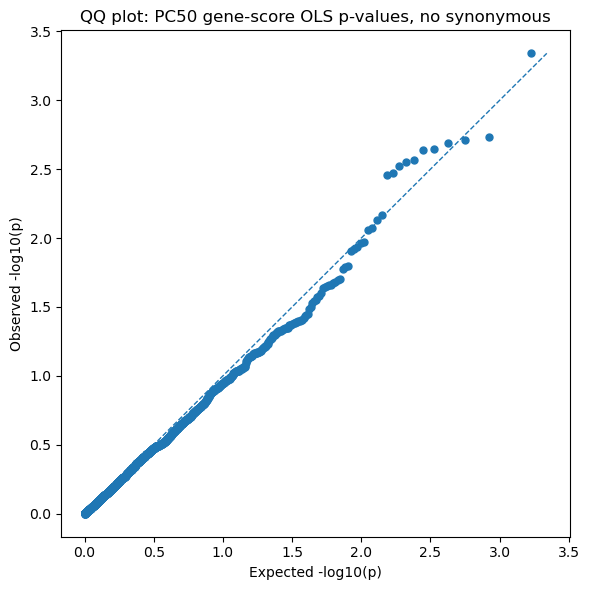


Rows before Manhattan chromosome filtering: 1685
          Gene_ID        CHROM  CHR_NUM  Gene_mid_POS  OLS_p_PC50
0   PF3D7_1139100  Pf3D7_11_v3       11     1551097.0    0.000457
1   PF3D7_0805300  Pf3D7_08_v3        8      297218.5    0.001839
2   PF3D7_0824300  Pf3D7_08_v3        8     1061035.5    0.001936
3   PF3D7_1462500  Pf3D7_14_v3       14     2546699.0    0.002026
4   PF3D7_0725100  Pf3D7_07_v3        7     1066610.0    0.002263
5   PF3D7_0207700  Pf3D7_02_v3        2      310856.0    0.002282
6   PF3D7_0425250  Pf3D7_01_v3        1     1138146.5    0.002712
7   PF3D7_1136900  Pf3D7_11_v3       11     1456323.0    0.002828
8   PF3D7_1023700  Pf3D7_10_v3       10      991894.0    0.003015
9   PF3D7_1356200  Pf3D7_13_v3       13     2228893.0    0.003365
10  PF3D7_1019000  Pf3D7_10_v3       10      759910.0    0.003473
11  PF3D7_0616400  Pf3D7_06_v3        6      681100.0    0.006833
12  PF3D7_0301400  Pf3D7_03_v3        3       85586.5    0.007400
13  PF3D7_1416600  Pf3D7_1

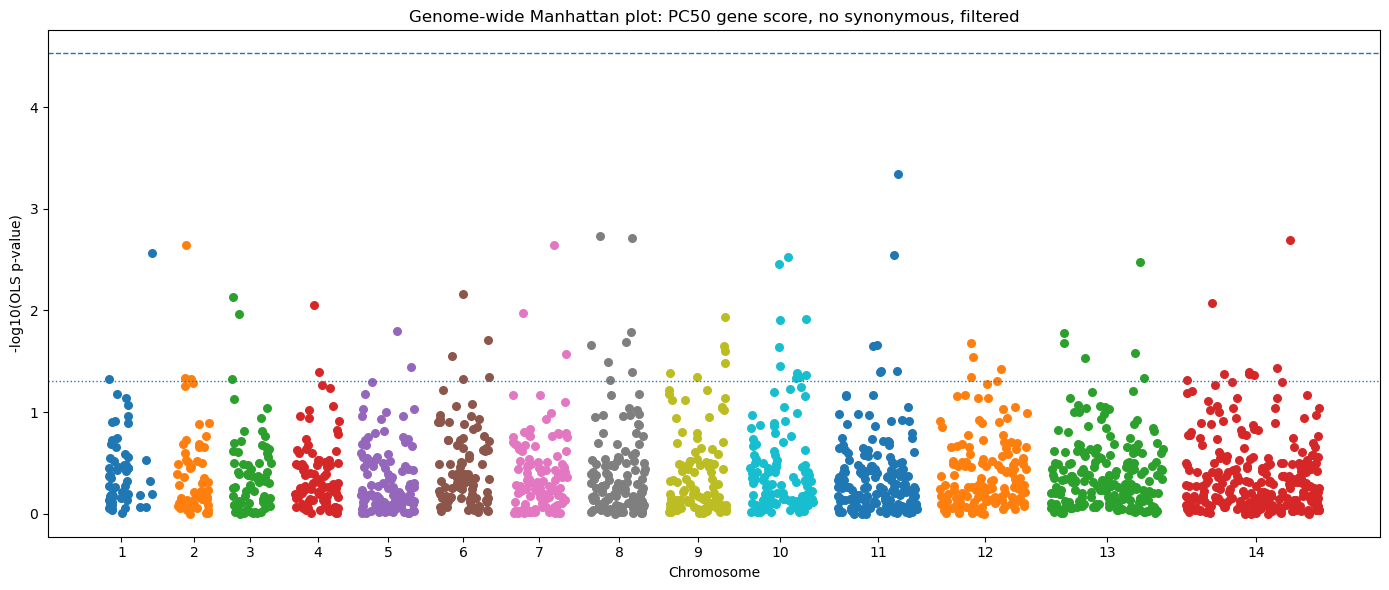

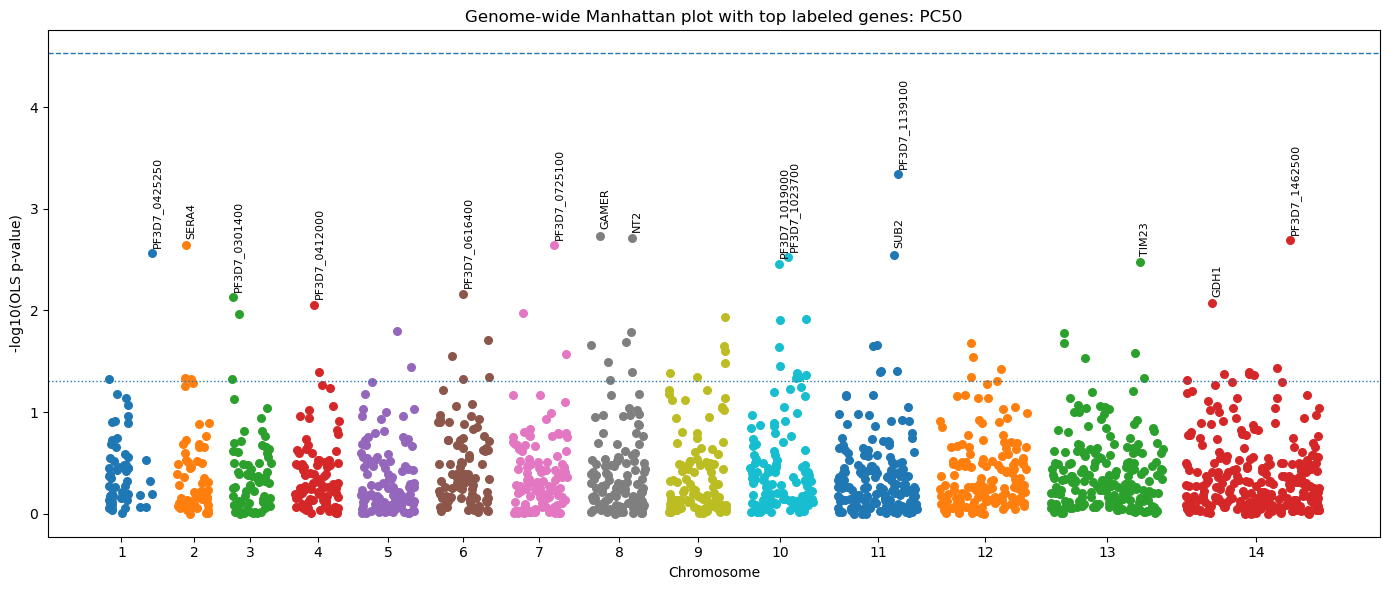


Examples of closest intergenic SNP assignments within 50 kb:
                SNP_ID       Gene_ID Common_name  Distance_to_gene_bp            Effect
Pf3D7_02_v3:106230:T>G PF3D7_0202100       LSAP2               3525.0 intergenic_region
Pf3D7_02_v3:109073:G>C PF3D7_0202100       LSAP2                682.0 intergenic_region
Pf3D7_02_v3:109248:C>G PF3D7_0202100       LSAP2                507.0 intergenic_region
Pf3D7_02_v3:112093:G>A PF3D7_0202100       LSAP2               2048.0 intergenic_region
Pf3D7_02_v3:119335:A>C PF3D7_0202400                           1567.0 intergenic_region
Pf3D7_02_v3:119979:C>A PF3D7_0202400                            923.0 intergenic_region
Pf3D7_02_v3:120002:A>C PF3D7_0202400                            900.0 intergenic_region
Pf3D7_02_v3:120086:A>T PF3D7_0202400                            816.0 intergenic_region
Pf3D7_02_v3:120161:A>T PF3D7_0202400                            741.0 intergenic_region
Pf3D7_02_v3:120248:G>A PF3D7_0202400                      

In [5]:
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu, ranksums
from statsmodels.stats.multitest import multipletests

# ============================================================
# FILE
# ============================================================
possible_files = [
    "ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv",
    "ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1(2).csv",
    "/mnt/data/ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1.csv",
    "/mnt/data/ALL_BD_ISOLATE_VCF_TO_CSV - Sheet1(2).csv"
]

vcf_csv = None
for f in possible_files:
    if os.path.exists(f):
        vcf_csv = f
        break

if vcf_csv is None:
    raise FileNotFoundError("VCF CSV file not found.")

print("Using file:", vcf_csv)

geno = pd.read_csv(vcf_csv, low_memory=False)
geno.columns = [str(c).strip() for c in geno.columns]

# ============================================================
# PARAMETERS
# ============================================================
MAX_DIST = 50_000
MIN_SNPS_PER_GENE = 2

MIN_ALT_COUNT = 2
MIN_REF_COUNT = 2
MIN_UNIQUE_SCORES = 3
MIN_SCORE_SD = 1e-6

# ============================================================
# PC50 PHENOTYPE
# PC50 >= 5 = delayed/high PC50
# PC50 < 5 = low PC50
# ============================================================
pc50 = pd.DataFrame({
    "Sample": [
        "I-001-clone", "I-002", "I-003-clone", "I-004", "I-005",
        "I-008", "I-010", "I-011", "I-013", "I-016",
        "I-017", "I-018", "I-019", "I-020", "I-021",
        "I-025", "I-026", "I-027", "I-029", "I-030",
        "I-031", "I-033", "I-035", "I-036", "I-039",
        "I-040-", "I-041"
    ],
    "PC50": [
        0.015, 3.56, 5.967, 1.6, 3.82,
        2.71, 2.01, 5.35, 7.98, 10.25,
        4.51, 3.42, 2.02, 7.66, 2.83,
        3.39, 3.25, 3.23, 7.68, 8.19,
        3.41, 8.48, 1.25, 9.42, 13.14,
        3.14, 4.82
    ]
})

pc50["Sample"] = pc50["Sample"].astype(str).str.strip()
pc50["PC50"] = pd.to_numeric(pc50["PC50"], errors="coerce")
pc50 = pc50.dropna()

pc50["Binary"] = (pc50["PC50"] >= 5).astype(int)
pc50["Group"] = np.where(pc50["PC50"] >= 5, "Delayed_PC50", "Low_PC50")
pc50 = pc50.set_index("Sample")

print("\nPC50 group counts:")
print(pc50["Group"].value_counts())

# ============================================================
# SAMPLE MATCHING
# ============================================================
if "FORMAT" not in geno.columns:
    raise ValueError("FORMAT column not found.")

format_idx = list(geno.columns).index("FORMAT")
vcf_samples = [str(x).strip() for x in geno.columns[format_idx + 1:]]

common = sorted(set(vcf_samples).intersection(set(pc50.index)))

print("\nSamples in VCF:", len(vcf_samples))
print("Samples with PC50:", pc50.shape[0])
print("Matched samples:", len(common))
print(common)

if len(common) == 0:
    raise ValueError("No matching samples between PC50 table and VCF CSV.")

pc50_data = pc50.loc[common].copy()

# ============================================================
# REQUIRED COLUMNS
# ============================================================
chrom_col = "#CHROM" if "#CHROM" in geno.columns else "CHROM"

for c in [chrom_col, "POS", "REF", "ALT", "INFO", "FORMAT"]:
    if c not in geno.columns:
        raise ValueError(f"Missing required column: {c}")

geno["POS"] = pd.to_numeric(geno["POS"], errors="coerce")
geno = geno.dropna(subset=["POS"]).copy()
geno["POS"] = geno["POS"].astype(int)

geno["SNP_ID"] = geno.apply(
    lambda r: f"{r[chrom_col]}:{int(r['POS'])}:{r['REF']}>{r['ALT']}",
    axis=1
)

# ============================================================
# ALT MATRIX
# ============================================================
def alt_present(x):
    if pd.isna(x):
        return 0.0

    gt = str(x).split(":")[0]

    if gt in ["./.", ".|.", ".", "nan", "None"]:
        return 0.0

    alleles = re.split(r"[\/|]", gt)
    return 1.0 if "1" in alleles else 0.0

A = pd.DataFrame(
    {s: geno[s].map(alt_present).values for s in common},
    index=geno["SNP_ID"]
).T

print("\nALT matrix shape:", A.shape)

# ============================================================
# PARSE ANN
# Drop synonymous variants
# Keep intergenic SNPs, collapse to closest candidate gene within 50 kb
# ============================================================
pf_gene_pattern = re.compile(r"PF3D7_\d{7}")

def clean_common_name(x):
    x = str(x).strip()

    if x in ["", ".", "nan", "NaN", "None", "null", "NULL"]:
        return ""

    if pf_gene_pattern.fullmatch(x):
        return ""

    if "_circ" in x:
        return ""

    return x

def is_synonymous_effect(effect):
    return "synonymous_variant" in str(effect)

gene_body_records = []
intergenic_raw_records = []
dropped_synonymous = 0

for _, row in geno.iterrows():

    info = str(row["INFO"])
    snp_id = row["SNP_ID"]
    chrom = row[chrom_col]
    pos = row["POS"]

    ann_field = None

    for field in info.split(";"):
        if field.startswith("ANN="):
            ann_field = field[4:]
            break

    if ann_field is None:
        continue

    for ann_record in ann_field.split(","):

        parts = ann_record.split("|")

        if len(parts) < 7:
            continue

        effect = parts[1]
        impact = parts[2]
        gene_name_field = parts[3]
        gene_id_field = parts[4]
        feature_type = parts[5]
        feature_id = parts[6]

        if is_synonymous_effect(effect):
            dropped_synonymous += 1
            continue

        text = "|".join([gene_id_field, feature_id, gene_name_field, ann_record])
        gene_ids = sorted(set(pf_gene_pattern.findall(text)))

        if len(gene_ids) == 0:
            continue

        if "intergenic_region" in effect:

            raw_common_names = str(gene_name_field).split("-")
            clean_names = [clean_common_name(x) for x in raw_common_names]
            clean_names = [x for x in clean_names if x != ""]

            intergenic_raw_records.append({
                "SNP_ID": snp_id,
                "CHROM": chrom,
                "POS": pos,
                "REF": row["REF"],
                "ALT": row["ALT"],
                "Candidate_Gene_IDs": gene_ids,
                "Candidate_common_names": clean_names,
                "Effect": effect,
                "Impact": impact,
                "Feature_type": feature_type,
                "Feature_ID": feature_id
            })

        else:

            common_name = clean_common_name(gene_name_field)

            for gene_id in gene_ids:
                gene_body_records.append({
                    "SNP_ID": snp_id,
                    "Gene_ID": gene_id,
                    "Common_name": common_name,
                    "CHROM": chrom,
                    "POS": pos,
                    "REF": row["REF"],
                    "ALT": row["ALT"],
                    "Effect": effect,
                    "Impact": impact,
                    "Feature_type": feature_type,
                    "Feature_ID": feature_id,
                    "Is_intergenic": False,
                    "Distance_to_gene_bp": 0,
                    "Assignment_rule": "gene_body_or_transcript_non_synonymous"
                })

gene_body_df = pd.DataFrame(gene_body_records)
intergenic_raw_df = pd.DataFrame(intergenic_raw_records)

print("\nDropped synonymous ANN records:", dropped_synonymous)
print("Gene-body/transcript non-synonymous assignments:", gene_body_df.shape[0])
print("Raw intergenic SNP records:", intergenic_raw_df.shape[0])

if gene_body_df.empty:
    raise ValueError("No non-synonymous gene-body/transcript annotations found.")

# ============================================================
# BUILD OBSERVED GENE INTERVALS FROM NON-SYNONYMOUS GENE-BODY SNPs
# ============================================================
gene_intervals = gene_body_df.groupby("Gene_ID").agg(
    CHROM=("CHROM", "first"),
    Gene_start_observed=("POS", "min"),
    Gene_end_observed=("POS", "max"),
    Gene_mid_observed=("POS", "median")
).reset_index()

gene_interval_dict = gene_intervals.set_index("Gene_ID").to_dict("index")

print("\nObserved gene intervals built for genes:", gene_intervals.shape[0])

# ============================================================
# COLLAPSE INTERGENIC SNPs TO CLOSEST CANDIDATE GENE
# ============================================================
intergenic_assigned_records = []

for _, row in intergenic_raw_df.iterrows():

    snp_pos = row["POS"]
    snp_chrom = row["CHROM"]

    candidate_rows = []

    for gene_id in row["Candidate_Gene_IDs"]:

        if gene_id not in gene_interval_dict:
            continue

        g = gene_interval_dict[gene_id]

        if g["CHROM"] != snp_chrom:
            continue

        gene_start = int(g["Gene_start_observed"])
        gene_end = int(g["Gene_end_observed"])

        if snp_pos < gene_start:
            dist = gene_start - snp_pos
        elif snp_pos > gene_end:
            dist = snp_pos - gene_end
        else:
            dist = 0

        candidate_rows.append({
            "Gene_ID": gene_id,
            "Distance_to_gene_bp": dist,
            "Gene_start_observed": gene_start,
            "Gene_end_observed": gene_end
        })

    if len(candidate_rows) == 0:
        continue

    candidate_df = pd.DataFrame(candidate_rows)

    min_dist = candidate_df["Distance_to_gene_bp"].min()

    if min_dist > MAX_DIST:
        continue

    closest_genes = candidate_df[
        candidate_df["Distance_to_gene_bp"] == min_dist
    ].copy()

    for _, closest in closest_genes.iterrows():

        gene_id = closest["Gene_ID"]

        common_name = ""

        if len(row["Candidate_common_names"]) == len(row["Candidate_Gene_IDs"]):
            gene_to_name = dict(zip(row["Candidate_Gene_IDs"], row["Candidate_common_names"]))
            common_name = gene_to_name.get(gene_id, "")

        if common_name == "":
            common_name = ";".join(row["Candidate_common_names"])

        intergenic_assigned_records.append({
            "SNP_ID": row["SNP_ID"],
            "Gene_ID": gene_id,
            "Common_name": common_name,
            "CHROM": row["CHROM"],
            "POS": row["POS"],
            "REF": row["REF"],
            "ALT": row["ALT"],
            "Effect": row["Effect"],
            "Impact": row["Impact"],
            "Feature_type": row["Feature_type"],
            "Feature_ID": row["Feature_ID"],
            "Is_intergenic": True,
            "Distance_to_gene_bp": float(min_dist),
            "Assignment_rule": "closest_intergenic_candidate_within_50kb"
        })

intergenic_df = pd.DataFrame(intergenic_assigned_records)

print("\nIntergenic SNPs assigned after closest-gene 50 kb filter:", intergenic_df.shape[0])

if not intergenic_df.empty:
    print("\nIntergenic distance summary:")
    print(intergenic_df["Distance_to_gene_bp"].describe())

# ============================================================
# FINAL ASSIGNMENT TABLE
# ============================================================
assign = pd.concat(
    [gene_body_df, intergenic_df],
    ignore_index=True
)

assign = assign.drop_duplicates(
    subset=["SNP_ID", "Gene_ID", "Effect", "Is_intergenic"]
).copy()

assign = assign[
    ~assign["Effect"].astype(str).str.contains("synonymous_variant", na=False)
].copy()

print("\nTotal SNP-to-gene assignments after dropping synonymous:", assign.shape[0])
print("Unique SNPs assigned:", assign["SNP_ID"].nunique())
print("Unique genes assigned:", assign["Gene_ID"].nunique())

print("\nAssignment type:")
print(assign["Is_intergenic"].value_counts())

print("\nTop effects after dropping synonymous:")
print(assign["Effect"].value_counts().head(30))

assign.to_csv("SNP_to_gene_assignments_PC50_no_synonymous_closest_intergenic_50kb.csv", index=False)

# ============================================================
# COMMON GENE NAMES
# ============================================================
def collapse_names(x):
    vals = []

    for item in x.dropna().astype(str):
        for z in item.split(";"):
            z = clean_common_name(z)
            if z != "":
                vals.append(z)

    return ";".join(sorted(set(vals)))

gene_names = assign.groupby("Gene_ID")["Common_name"].apply(
    collapse_names
).reset_index()

# ============================================================
# GENE SCORE ASSOCIATION WITH VARIATION FILTERS
# ============================================================
results = []

for gene_id, gdf in assign.groupby("Gene_ID"):

    snps_all = sorted(set(gdf["SNP_ID"]).intersection(A.columns))

    if len(snps_all) == 0:
        continue

    A_gene = A[snps_all].copy()

    alt_counts = A_gene.sum(axis=0)
    n_samples = A_gene.shape[0]
    ref_counts = n_samples - alt_counts

    keep_snps = alt_counts[
        (alt_counts >= MIN_ALT_COUNT) &
        (ref_counts >= MIN_REF_COUNT)
    ].index.tolist()

    if len(keep_snps) < MIN_SNPS_PER_GENE:
        continue

    A_gene = A_gene[keep_snps].copy()

    maf = A_gene.mean(axis=0)

    variable_snps = maf[(maf > 0) & (maf < 1)].index.tolist()

    if len(variable_snps) < MIN_SNPS_PER_GENE:
        continue

    A_gene = A_gene[variable_snps].copy()
    maf = A_gene.mean(axis=0)

    weights = 1 / np.sqrt(maf * (1 - maf))
    weights = weights.replace([np.inf, -np.inf], 0).fillna(0)

    gene_score = ((A_gene * weights) ** 2).sum(axis=1)

    df = pd.DataFrame({
        "Score": gene_score,
        "PC50": pc50_data.loc[gene_score.index, "PC50"],
        "Binary": pc50_data.loc[gene_score.index, "Binary"],
        "Group": pc50_data.loc[gene_score.index, "Group"]
    }).dropna()

    if df["Score"].nunique() < MIN_UNIQUE_SCORES:
        continue

    if df["Score"].std() <= MIN_SCORE_SD:
        continue

    low = df[df["Binary"] == 0]["Score"]
    delayed = df[df["Binary"] == 1]["Score"]

    if len(low) < 2 or len(delayed) < 2:
        continue

    if low.nunique() < 2 and delayed.nunique() < 2:
        continue

    try:
        X = sm.add_constant(df["Score"])
        fit = sm.OLS(df["PC50"], X).fit()
        ols_beta = fit.params.iloc[1]
        ols_p = fit.pvalues.iloc[1]
        ols_r2 = fit.rsquared
    except Exception:
        ols_beta = np.nan
        ols_p = np.nan
        ols_r2 = np.nan

    try:
        welch_p = ttest_ind(low, delayed, equal_var=False).pvalue
    except Exception:
        welch_p = np.nan

    try:
        mw_p = mannwhitneyu(low, delayed, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan

    try:
        rank_p = ranksums(low, delayed).pvalue
    except Exception:
        rank_p = np.nan

    try:
        logit = sm.Logit(df["Binary"], sm.add_constant(df["Score"])).fit(disp=0)
        logit_beta = logit.params.iloc[1]
        logit_p = logit.pvalues.iloc[1]
        logit_or = np.exp(logit_beta)
    except Exception:
        logit_beta = np.nan
        logit_p = np.nan
        logit_or = np.nan

    gdf_used = gdf[gdf["SNP_ID"].isin(variable_snps)].copy()

    n_intergenic = int(gdf_used["Is_intergenic"].sum())
    n_gene_body = int((~gdf_used["Is_intergenic"]).sum())

    intergenic_dist = gdf_used.loc[
        gdf_used["Is_intergenic"],
        "Distance_to_gene_bp"
    ]

    max_dist = intergenic_dist.max() if len(intergenic_dist) > 0 else 0
    mean_dist = intergenic_dist.mean() if len(intergenic_dist) > 0 else 0

    results.append({
        "Gene_ID": gene_id,
        "CHROM": gdf["CHROM"].iloc[0],
        "Gene_mid_POS": gdf["POS"].median(),
        "Min_POS": gdf["POS"].min(),
        "Max_POS": gdf["POS"].max(),
        "N_SNPs_used": len(variable_snps),
        "N_intergenic_SNP_assignments_50kb": n_intergenic,
        "N_gene_body_or_transcript_SNP_assignments": n_gene_body,
        "Max_intergenic_distance_bp": max_dist,
        "Mean_intergenic_distance_bp": mean_dist,
        "SNPs_used": ";".join(variable_snps),
        "Effects_used": ";".join(sorted(gdf_used["Effect"].dropna().unique())),
        "Mean_score_low_PC50_lt_5": low.mean(),
        "Mean_score_delayed_PC50_ge_5": delayed.mean(),
        "Difference_delayed_minus_low": delayed.mean() - low.mean(),
        "OLS_beta_PC50": ols_beta,
        "OLS_p_PC50": ols_p,
        "OLS_R2_PC50": ols_r2,
        "Welch_p": welch_p,
        "MannWhitney_p": mw_p,
        "Wilcoxon_rank_sum_p": rank_p,
        "Logistic_beta": logit_beta,
        "Logistic_p": logit_p,
        "Logistic_OR": logit_or
    })

res = pd.DataFrame(results)

print("\nNumber of tested genes:", res.shape[0])
print("Result columns:", res.columns.tolist())

if res.empty:
    raise ValueError("No genes passed filters.")

# ============================================================
# ADD COMMON NAME
# ============================================================
res = res.merge(gene_names, on="Gene_ID", how="left")

# ============================================================
# FDR
# ============================================================
for pcol in ["OLS_p_PC50", "Welch_p", "MannWhitney_p", "Logistic_p"]:

    res[pcol + "_FDR"] = np.nan

    valid = res[pcol].notna() & (res[pcol] > 0) & (res[pcol] <= 1)

    if valid.sum() > 0:
        res.loc[valid, pcol + "_FDR"] = multipletests(
            res.loc[valid, pcol],
            method="fdr_bh"
        )[1]

res = res.sort_values("OLS_p_PC50", na_position="last").reset_index(drop=True)

# ============================================================
# FINAL TABLE
# ============================================================
final_cols = [
    "Gene_ID",
    "Common_name",
    "CHROM",
    "Gene_mid_POS",
    "Min_POS",
    "Max_POS",
    "N_SNPs_used",
    "N_intergenic_SNP_assignments_50kb",
    "N_gene_body_or_transcript_SNP_assignments",
    "Max_intergenic_distance_bp",
    "Mean_intergenic_distance_bp",
    "Effects_used",
    "Mean_score_low_PC50_lt_5",
    "Mean_score_delayed_PC50_ge_5",
    "Difference_delayed_minus_low",
    "OLS_beta_PC50",
    "OLS_p_PC50",
    "OLS_p_PC50_FDR",
    "OLS_R2_PC50",
    "Welch_p",
    "Welch_p_FDR",
    "MannWhitney_p",
    "MannWhitney_p_FDR",
    "Logistic_p",
    "Logistic_p_FDR",
    "Logistic_OR",
    "SNPs_used"
]

final_table = res[final_cols].copy()

out_csv = "Genomewide_PC50_gene_score_NO_SYNONYMOUS_filtered_FIXED_MANHATTAN.csv"
final_table.to_csv(out_csv, index=False)

print("\nTop 30 genome-wide gene results:")
print(final_table.head(30).to_string(index=False))

print("\nSaved final table:")
print(out_csv)

# ============================================================
# QQ PLOT
# ============================================================
qq = res.dropna(subset=["OLS_p_PC50"]).copy()
qq = qq[(qq["OLS_p_PC50"] > 0) & (qq["OLS_p_PC50"] <= 1)].copy()

pvals = np.sort(qq["OLS_p_PC50"].values)

observed = -np.log10(pvals)
expected = -np.log10(np.arange(1, len(pvals) + 1) / (len(pvals) + 1))

plt.figure(figsize=(6, 6))
plt.scatter(expected, observed, s=25)

max_val = max(expected.max(), observed.max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot: PC50 gene-score OLS p-values, no synonymous")

plt.tight_layout()
plt.show()

# ============================================================
# MANHATTAN PLOT
# ============================================================
def chrom_number(x):
    x = str(x)
    m = re.search(r"Pf3D7_(\d+)_v3", x)
    return int(m.group(1)) if m else np.nan

man = res.dropna(subset=["OLS_p_PC50", "CHROM", "Gene_mid_POS"]).copy()
man = man[(man["OLS_p_PC50"] > 0) & (man["OLS_p_PC50"] <= 1)].copy()

man["CHR_NUM"] = man["CHROM"].apply(chrom_number)

print("\nRows before Manhattan chromosome filtering:", man.shape[0])
print(man[["Gene_ID", "CHROM", "CHR_NUM", "Gene_mid_POS", "OLS_p_PC50"]].head(20))

man = man.dropna(subset=["CHR_NUM"]).copy()

if man.empty:
    raise ValueError("No valid rows for Manhattan plot after CHROM parsing.")

man["CHR_NUM"] = man["CHR_NUM"].astype(int)
man["Gene_mid_POS"] = pd.to_numeric(man["Gene_mid_POS"], errors="coerce")
man = man.dropna(subset=["Gene_mid_POS"]).copy()

man = man.sort_values(["CHR_NUM", "Gene_mid_POS"]).copy()

chr_centers = {}
offset = 0
cum_positions = []

for chrom in sorted(man["CHR_NUM"].unique()):

    sub = man[man["CHR_NUM"] == chrom].copy()

    x = sub["Gene_mid_POS"] + offset
    cum_positions.extend(x.tolist())

    chr_centers[chrom] = x.mean()

    offset = x.max() + 500000

man["BP_cum"] = cum_positions
man["minus_log10_p"] = -np.log10(man["OLS_p_PC50"])

plt.figure(figsize=(14, 6))

for chrom in sorted(man["CHR_NUM"].unique()):
    sub = man[man["CHR_NUM"] == chrom]

    plt.scatter(
        sub["BP_cum"],
        sub["minus_log10_p"],
        s=30
    )

bonf = 0.05 / man.shape[0]

plt.axhline(-np.log10(bonf), linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), linestyle=":", linewidth=1)

plt.xticks(
    [chr_centers[c] for c in sorted(chr_centers)],
    [str(c) for c in sorted(chr_centers)]
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(OLS p-value)")
plt.title("Genome-wide Manhattan plot: PC50 gene score, no synonymous, filtered")

plt.tight_layout()
plt.show()

# ============================================================
# LABELED MANHATTAN
# ============================================================
top_n = 15
top_hits = man.nsmallest(top_n, "OLS_p_PC50").copy()

plt.figure(figsize=(14, 6))

for chrom in sorted(man["CHR_NUM"].unique()):
    sub = man[man["CHR_NUM"] == chrom]

    plt.scatter(
        sub["BP_cum"],
        sub["minus_log10_p"],
        s=30
    )

plt.axhline(-np.log10(bonf), linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), linestyle=":", linewidth=1)

for _, row in top_hits.iterrows():

    common_name = str(row["Common_name"]).strip()

    if common_name in ["", "nan", "None"]:
        label = row["Gene_ID"]
    else:
        label = common_name.split(";")[0]

    plt.text(
        row["BP_cum"],
        row["minus_log10_p"] + 0.08,
        label,
        fontsize=8,
        rotation=90,
        ha="left"
    )

plt.xticks(
    [chr_centers[c] for c in sorted(chr_centers)],
    [str(c) for c in sorted(chr_centers)]
)

plt.xlabel("Chromosome")
plt.ylabel("-log10(OLS p-value)")
plt.title("Genome-wide Manhattan plot with top labeled genes: PC50")

plt.tight_layout()
plt.show()

# ============================================================
# SANITY CHECK
# ============================================================
print("\nExamples of closest intergenic SNP assignments within 50 kb:")
if intergenic_df.empty:
    print("No intergenic SNPs were assigned within 50 kb.")
else:
    print(
        intergenic_df[
            ["SNP_ID", "Gene_ID", "Common_name", "Distance_to_gene_bp", "Effect"]
        ]
        .drop_duplicates()
        .head(50)
        .to_string(index=False)
    )

print("\nMaximum intergenic distance included:")
if intergenic_df.empty:
    print("None")
else:
    print(intergenic_df["Distance_to_gene_bp"].max())

print("\nCheck that synonymous variants were removed:")
print(assign["Effect"].astype(str).str.contains("synonymous_variant", na=False).value_counts())